# ROPAgen Document Evaluation
## ModernBERT-based NLP Metrics for 2,000-Token German GDPR Documents

**Metrics:** BLEU · ROUGE-1/2/L · METEOR · BERTScore Recall · SBERT Cosine Similarity  
**Model:** `answerdotai/ModernBERT-base` — Alternating Global-Local Attention + RoPE, 8,192-token native window  
**Hardware target:** RTX 4070 (CUDA) with batch processing to prevent OOM

In [70]:
import os, warnings
warnings.filterwarnings("ignore")

from dotenv import load_dotenv
load_dotenv()   # loads HF_TOKEN (and any other vars) from .env

import pandas as pd
import numpy as np
import torch
import evaluate
from transformers import AutoTokenizer, AutoModel
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm.auto import tqdm

# ── Configuration ──────────────────────────────────────────────────────────────
MODEL_NAME       = "answerdotai/ModernBERT-base"
DEVICE           = "cuda" if torch.cuda.is_available() else "cpu"
BERT_BATCH_SIZE  = 4   # conservative for RTX 4070 + 2k-token docs
SBERT_BATCH_SIZE = 4

print(f"Device : {DEVICE}")
if DEVICE == "cuda":
    props = torch.cuda.get_device_properties(0)
    print(f"GPU    : {props.name}")
    print(f"VRAM   : {props.total_memory / 1e9:.1f} GB")
print(f"HF_TOKEN set: {bool(os.environ.get('HF_TOKEN'))}")

Device : cuda
GPU    : NVIDIA GeForce RTX 4070
VRAM   : 12.9 GB
HF_TOKEN set: True


In [71]:
# ── Load reference document ────────────────────────────────────────────────────
with open("docs/reference.txt", "r", encoding="utf-8") as fh:
    reference_text = fh.read().strip()

print(f"Reference length : {len(reference_text):,} chars  |  "
      f"~{len(reference_text.split()):,} words")

# ── Load candidate documents ───────────────────────────────────────────────────
df_all = pd.read_csv("docs/documents.csv")
df_all = df_all.dropna(subset=["ai_mode"])   # drop rows with missing ai_mode
print(f"\nTotal candidates : {len(df_all)}")
print(f"Columns          : {df_all.columns.tolist()}")
print(f"\nMode distribution:")
print(df_all["ai_mode"].value_counts().to_string())

# ── Split by mode ──────────────────────────────────────────────────────────────
MODES = sorted(df_all["ai_mode"].unique().tolist())
dfs_by_mode = {
    mode: df_all[df_all["ai_mode"] == mode].reset_index(drop=True)
    for mode in MODES
}
print(f"\nMode keys: {MODES}")

Reference length : 3,532 chars  |  ~393 words

Total candidates : 113
Columns          : ['id', 'user_id', 'ai_mode', 'document']

Mode distribution:
ai_mode
chat    39
form    37
ask     37

Mode keys: ['ask', 'chat', 'form']


## Metric Definitions

| Metric | Purpose | Notes |
|---|---|---|
| **BLEU** | N-gram precision overlap | Modified precision; baseline surface similarity |
| **ROUGE-1/2** | Unigram / bigram recall | Measures lexical coverage |
| **ROUGE-L** | Longest common subsequence | Captures sentence-level structure |
| **METEOR** | Synonym-aware recall | Stems + synonyms → better semantic recall than BLEU |
| **BERTScore Recall** | Token-level contextual overlap | ModernBERT embeddings; focus on *recall* per supervisor |
| **SBERT Similarity** | Global document-level cosine sim | Pooled ModernBERT embeddings; holistic semantic match |

In [72]:
# ── Load evaluate metrics (done once; reused across modes) ─────────────────────
print("Loading evaluate metrics …")
bleu_metric    = evaluate.load("bleu")
rouge_metric   = evaluate.load("rouge")
meteor_metric  = evaluate.load("meteor")
print("Done.")

# ── Baseline: BLEU · ROUGE · METEOR ───────────────────────────────────────────
def compute_baseline_metrics(candidates: list[str], reference: str) -> pd.DataFrame:
    """
    Compute BLEU, ROUGE-1, ROUGE-2, ROUGE-L, and METEOR document-by-document.

    METEOR is highlighted because it matches stems and WordNet synonyms,
    giving more credit for paraphrased recall than BLEU's precision-only view.
    """
    rows = []
    for cand in tqdm(candidates, desc="  baseline", leave=False):
        row = {}

        # BLEU — modified n-gram precision (references wrapped in a list)
        try:
            b = bleu_metric.compute(predictions=[cand], references=[[reference]])
            row["BLEU"] = b["bleu"]
        except Exception:
            row["BLEU"] = np.nan

        # ROUGE
        r = rouge_metric.compute(predictions=[cand], references=[reference])
        row["ROUGE-1"] = r["rouge1"]
        row["ROUGE-2"] = r["rouge2"]
        row["ROUGE-L"] = r["rougeL"]

        # METEOR — synonym-aware recall via stemming + WordNet alignment
        m = meteor_metric.compute(predictions=[cand], references=[reference])
        row["METEOR"] = m["meteor"]

        rows.append(row)

    return pd.DataFrame(rows)

Loading evaluate metrics …
Done.


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\emilija\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\emilija\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\emilija\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [73]:
import torch.nn.functional as F

# ── Load ModernBERT once for BERTScore (evaluate's bert_score library does not
#    support ModernBERT's architecture — we call AutoModel directly instead) ────
print(f"Loading tokenizer & model for BERTScore: {MODEL_NAME} …")
_bert_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
_bert_model     = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
_bert_model.eval()
print("Done.")


def _embed_texts(texts: list[str], batch_size: int) -> list[torch.Tensor]:
    """Return one L2-normalised (valid_tokens × hidden_dim) tensor per text."""
    embeddings: list[torch.Tensor] = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        enc = _bert_tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=8192,
            return_tensors="pt",
        ).to(DEVICE)
        with torch.no_grad():
            out = _bert_model(**enc)
        hidden = out.last_hidden_state        # (B, T, H)
        mask   = enc["attention_mask"].bool() # (B, T)
        for j in range(len(batch)):
            emb = hidden[j][mask[j]]          # strip padding → (T_valid, H)
            embeddings.append(F.normalize(emb, dim=-1))
        if DEVICE == "cuda":
            torch.cuda.empty_cache()
    return embeddings


def compute_bertscore(
    candidates: list[str],
    reference: str,
    batch_size: int = BERT_BATCH_SIZE,
) -> tuple[list[float], list[float], list[float]]:
    """
    BERTScore Precision, Recall, and F1 using ModernBERT token embeddings.

    P_BERT  = mean over candidate tokens of max cosine sim to any reference token
    R_BERT  = mean over reference tokens  of max cosine sim to any candidate token
    F1_BERT = harmonic mean of P and R

    Because embeddings are L2-normalised, cosine sim = dot product.
    """
    [ref_emb] = _embed_texts([reference], batch_size=1)   # (T_ref, H)
    cand_embs  = _embed_texts(candidates, batch_size=batch_size)

    precisions, recalls, f1s = [], [], []
    for c_emb in tqdm(cand_embs, desc="  BERTScore", leave=False):
        sim = ref_emb @ c_emb.T                          # (T_ref, T_cand)
        r   = sim.max(dim=1).values.mean().item()        # recall:    max over cand per ref token
        p   = sim.max(dim=0).values.mean().item()        # precision: max over ref  per cand token
        f1  = (2 * p * r / (p + r)) if (p + r) > 0 else 0.0
        precisions.append(p)
        recalls.append(r)
        f1s.append(f1)

    return precisions, recalls, f1s

Loading tokenizer & model for BERTScore: answerdotai/ModernBERT-base …


Loading weights: 100%|██████████| 134/134 [00:00<00:00, 13930.42it/s]
ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     |  | 
------------------+------------+--+-
decoder.bias      | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Done.


In [74]:
# ── SBERT Global Semantic Similarity (ModernBERT-base, CUDA, batched) ──────────
print(f"Loading SentenceTransformer: {MODEL_NAME} …")
sbert_model = SentenceTransformer(MODEL_NAME, device=DEVICE)

# Override the default 512-token limit; ModernBERT supports 8,192 natively
sbert_model.max_seq_length = 8192
print(f"Max seq length : {sbert_model.max_seq_length}")
print(f"Embedding dim  : {sbert_model.get_sentence_embedding_dimension()}")

# Pre-encode the reference once (reused for every mode)
ref_embedding = sbert_model.encode(
    [reference_text],
    batch_size=1,
    convert_to_numpy=True,
    normalize_embeddings=True,   # L2-normalise → dot product == cosine sim
    show_progress_bar=False,
)   # shape: (1, hidden_dim)

def compute_sbert_similarity(
    candidates: list[str],
    batch_size: int = SBERT_BATCH_SIZE,
) -> list[float]:
    """
    Encode each candidate with the shared ModernBERT SentenceTransformer and
    compute cosine similarity against the pre-encoded reference embedding.

    Because both vectors are L2-normalised, cosine similarity reduces to a
    simple dot product — no extra trig needed.
    """
    cand_embeddings = sbert_model.encode(
        candidates,
        batch_size=batch_size,
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=False,
    )   # shape: (n, hidden_dim)

    # dot product of unit vectors == cosine similarity
    sims = (cand_embeddings @ ref_embedding.T).squeeze()

    if DEVICE == "cuda":
        torch.cuda.empty_cache()

    # ensure we always return a plain Python list
    return sims.tolist() if hasattr(sims, "tolist") else [float(sims)]

Loading SentenceTransformer: answerdotai/ModernBERT-base …


Loading weights: 100%|██████████| 134/134 [00:00<00:00, 15337.34it/s]
ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     |  | 
------------------+------------+--+-
decoder.bias      | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Max seq length : 8192
Embedding dim  : 768


In [75]:
# ── Compute all metrics per mode ───────────────────────────────────────────────
METRIC_COLS = ["BLEU", "ROUGE-1", "ROUGE-2", "ROUGE-L", "METEOR",
               "BERTScore_Precision", "BERTScore_Recall", "BERTScore_F1",
               "SBERT_ModernBERT"]

mode_results: dict[str, pd.DataFrame] = {}

for mode in MODES:
    df_mode    = dfs_by_mode[mode]
    candidates = df_mode["document"].astype(str).tolist()
    n          = len(candidates)

    print(f"\n{'═'*60}")
    print(f"  Mode: '{mode}'  ({n} documents)")
    print(f"{'═'*60}")

    # 1. Lexical / surface metrics
    df_base = compute_baseline_metrics(candidates, reference_text)

    # 2. BERTScore Precision, Recall, F1 — ModernBERT token-level
    precisions, recalls, f1s = compute_bertscore(candidates, reference_text)

    # 3. SBERT Cosine Similarity — global document-level semantic similarity
    sims = compute_sbert_similarity(candidates)

    # Assemble per-mode DataFrame
    df_result = df_mode[["id", "user_id", "ai_mode"]].copy()
    df_result = pd.concat(
        [df_result.reset_index(drop=True),
         df_base.reset_index(drop=True),
         pd.Series(precisions, name="BERTScore_Precision"),
         pd.Series(recalls,    name="BERTScore_Recall"),
         pd.Series(f1s,        name="BERTScore_F1"),
         pd.Series(sims,       name="SBERT_ModernBERT")],
        axis=1,
    )

    mode_results[mode] = df_result


════════════════════════════════════════════════════════════
  Mode: 'ask'  (37 documents)
════════════════════════════════════════════════════════════



════════════════════════════════════════════════════════════
  Mode: 'chat'  (39 documents)
════════════════════════════════════════════════════════════



════════════════════════════════════════════════════════════
  Mode: 'form'  (37 documents)
════════════════════════════════════════════════════════════


In [76]:
# ── Combine all modes into one master DataFrame ────────────────────────────────
df_combined = pd.concat(mode_results.values(), ignore_index=True)

print("=" * 65)
print(f"  COMBINED RESULTS  —  {len(df_combined)} document pairs  ×  {len(METRIC_COLS)} metrics")
print("=" * 65)


# ── Helper: describe() + median label + highest/lowest document ID ─────────────
def build_summary(df: pd.DataFrame) -> pd.DataFrame:
    stats = df[METRIC_COLS].describe().round(4)
    stats = stats.rename(index={"50%": "median"})
    stats.loc["highest_id"] = {col: df.loc[df[col].idxmax(), "id"] for col in METRIC_COLS}
    stats.loc["lowest_id"]  = {col: df.loc[df[col].idxmin(), "id"] for col in METRIC_COLS}
    return stats


# ── Overall (all modes combined) ───────────────────────────────────────────────
df_summary_overall = build_summary(df_combined)

# ── Per-mode detailed tables ───────────────────────────────────────────────────
df_summaries = {}
for mode in MODES:
    df_summaries[mode] = build_summary(mode_results[mode])

# ── Save ───────────────────────────────────────────────────────────────────────
OUT = "output"

df_combined.to_csv(f"{OUT}/document_results.csv", index=False)

print(f"Saved {OUT}/document_results.csv   — full per-document scores")


  COMBINED RESULTS  —  113 document pairs  ×  9 metrics
Saved output/document_results.csv   — full per-document scores


## Duration Analysis

Time elapsed (in minutes) measures how long each participant spent generating a single ROPA document in a given mode, as recorded by ropagen in the document text itself. Each document ends with a metadata block containing `Mode:` and `Time elapsed: X seconds`. This is a per-document measure — one value per participant per mode.

Document Generation Time by Mode (minutes)


,n,Mean (min),Std,Min (min),Max (min)
Mode,,,,,
Form,37,9.40,6.57,3.38,33.22
Ask,37,16.50,11.26,4.82,51.65
Chat,39,16.32,16.92,3.03,103.32
All,113,14.11,12.76,3.03,103.32


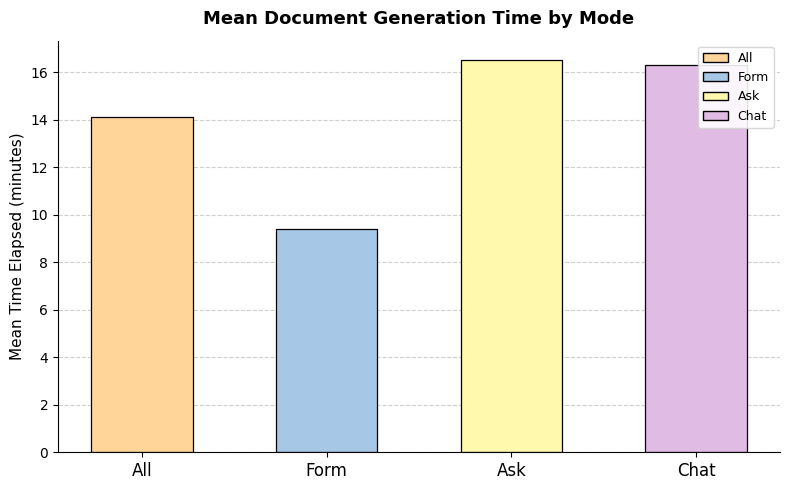

Saved → output/duration_by_mode.png


In [77]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display

# ── Extract Mode and Time elapsed from each document ─────────────────────────
# Each document contains a trailing metadata block with lines like:
#   Mode: chat
#   Time elapsed: 589 seconds

_elapsed_re = re.compile(r"Time elapsed:\s*(\d+)\s*seconds", re.IGNORECASE)

def extract_elapsed(text: str):
    m = _elapsed_re.search(str(text))
    return int(m.group(1)) if m else None

df_dur = df_all.copy()
df_dur["elapsed_sec"] = df_dur["document"].apply(extract_elapsed)

missing = df_dur["elapsed_sec"].isna().sum()
if missing:
    print(f"Warning: {missing} document(s) had no parseable 'Time elapsed' line — excluded.")
df_dur = df_dur.dropna(subset=["elapsed_sec"]).copy()

df_dur["elapsed_min"] = df_dur["elapsed_sec"] / 60
df_dur["mode_label"]  = df_dur["ai_mode"].str.strip().str.title()

# ── Summary table ─────────────────────────────────────────────────────────────
MODE_ORDER = ["Form", "Ask", "Chat"]
rows   = []
groups = {}

for label in MODE_ORDER:
    vals = df_dur[df_dur["mode_label"] == label]["elapsed_min"]
    groups[label] = vals
    rows.append({
        "Mode":       label,
        "n":          int(vals.count()),
        "Mean (min)": round(vals.mean(), 2),
        "Std":        round(vals.std(),  2),
        "Min (min)":  round(vals.min(),  2),
        "Max (min)":  round(vals.max(),  2),
    })

all_vals = df_dur["elapsed_min"]
rows.append({
    "Mode":       "All",
    "n":          int(all_vals.count()),
    "Mean (min)": round(all_vals.mean(), 2),
    "Std":        round(all_vals.std(),  2),
    "Min (min)":  round(all_vals.min(),  2),
    "Max (min)":  round(all_vals.max(),  2),
})

df_dur_summary = pd.DataFrame(rows).set_index("Mode")
print("Document Generation Time by Mode (minutes)")
display(df_dur_summary)

# ── Bar chart ─────────────────────────────────────────────────────────────────
GROUPS_ORDER = ["All",     "Form",    "Ask",     "Chat"]
BAR_COLORS   = ["#FFD59A", "#A7C7E7", "#FFF9AE", "#E0BBE4"]

means_plot = [all_vals.mean()] + [groups[m].mean() for m in ["Form", "Ask", "Chat"]]

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(GROUPS_ORDER))

ax.bar(
    x, means_plot,
    color=BAR_COLORS,
    edgecolor="black",
    linewidth=0.9,
    width=0.55,
)

ax.set_xticks(x)
ax.set_xticklabels(GROUPS_ORDER, fontsize=12)
ax.set_ylabel("Mean Time Elapsed (minutes)", fontsize=11)
ax.set_title("Mean Document Generation Time by Mode", fontsize=13, fontweight="bold", pad=12)
ax.yaxis.grid(True, linestyle="--", linewidth=0.8, alpha=0.6)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

legend_handles = [
    mpatches.Patch(facecolor=bc, edgecolor="black", label=g)
    for g, bc in zip(GROUPS_ORDER, BAR_COLORS)
]
ax.legend(handles=legend_handles, fontsize=9, framealpha=0.88,
          edgecolor="lightgrey", loc="upper right")

plt.tight_layout()
OUT = "output"
fname_dur = f"{OUT}/duration_by_mode.png"
plt.savefig(fname_dur, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {fname_dur}")

## Per-Document Summaries

In [78]:
# ── Export: doc_nlp_summary.csv & doc_bert_summary.csv ──────────────────────
# Tidy per-metric summaries (n/min/q1/median/q3/max/mean/std + best/worst)
# across All, form, ask, chat groups, sourced from document_results.csv.

import pandas as pd

OUT = "output"

df_eval = pd.read_csv(f"{OUT}/document_results.csv")

NLP_METRICS  = ["BLEU", "ROUGE-1", "ROUGE-2", "ROUGE-L", "METEOR"]
BERT_METRICS = ["BERTScore_Precision", "BERTScore_Recall", "BERTScore_F1",
                "SBERT_ModernBERT"]


def build_doc_summary(df: pd.DataFrame, metrics: list) -> pd.DataFrame:
    """
    For each metric compute descriptive stats + best/worst user_id across
    All rows and per-mode subsets.  Returns a wide DataFrame (rows = metrics).
    """
    groups = {"All": df, "form": df[df["ai_mode"] == "form"],
              "ask":  df[df["ai_mode"] == "ask"],
              "chat": df[df["ai_mode"] == "chat"]}

    rows = []
    for metric in metrics:
        row = {"metric": metric}
        for grp_name, grp_df in groups.items():
            s = grp_df[metric]
            prefix = grp_name
            row[f"{prefix}_n"]          = int(s.count())
            row[f"{prefix}_min"]        = round(s.min(),  4)
            row[f"{prefix}_q1"]         = round(s.quantile(0.25), 4)
            row[f"{prefix}_median"]     = round(s.median(), 4)
            row[f"{prefix}_q3"]         = round(s.quantile(0.75), 4)
            row[f"{prefix}_max"]        = round(s.max(),  4)
            row[f"{prefix}_mean"]       = round(s.mean(), 4)
            row[f"{prefix}_std"]        = round(s.std(),  4)
            row[f"{prefix}_best_id"]    = grp_df.loc[grp_df[metric].idxmax(), "user_id"]
            row[f"{prefix}_best_score"] = round(grp_df[metric].max(), 4)
            row[f"{prefix}_worst_id"]   = grp_df.loc[grp_df[metric].idxmin(), "user_id"]
            row[f"{prefix}_worst_score"]= round(grp_df[metric].min(), 4)
        rows.append(row)
    return pd.DataFrame(rows)


df_doc_nlp  = build_doc_summary(df_eval, NLP_METRICS)
df_doc_bert = build_doc_summary(df_eval, BERT_METRICS)

df_doc_nlp.to_csv(f"{OUT}/doc_nlp_summary.csv",  index=False)
df_doc_bert.to_csv(f"{OUT}/doc_bert_summary.csv", index=False)

print(f"Saved {OUT}/doc_nlp_summary.csv  — {len(df_doc_nlp)} rows")
print(f"Saved {OUT}/doc_bert_summary.csv — {len(df_doc_bert)} rows")


Saved output/doc_nlp_summary.csv  — 5 rows
Saved output/doc_bert_summary.csv — 4 rows


In [79]:
# ── Display A: per-doc NLP + BERT summaries (one mode at a time) ─────────────
import pandas as pd
from IPython.display import display

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

OUT = "output"
df_doc_nlp_disp  = pd.read_csv(f"{OUT}/doc_nlp_summary.csv")
df_doc_bert_disp = pd.read_csv(f"{OUT}/doc_bert_summary.csv")

NLP_METRICS_DISP  = ["BLEU", "ROUGE-1", "ROUGE-2", "ROUGE-L", "METEOR"]
BERT_METRICS_DISP = ["BERTScore_Precision", "BERTScore_Recall", "BERTScore_F1",
                     "SBERT_ModernBERT"]
STAT_COLS = ["n", "min", "q1", "median", "q3", "max", "mean", "std",
             "best_id", "best_score", "worst_id", "worst_score"]

for mode in ["All", "form", "ask", "chat"]:
    print(f"── {mode} ──")

    # NLP table
    nlp_cols = [f"{mode}_{s}" for s in STAT_COLS]
    df_nlp_view = df_doc_nlp_disp[df_doc_nlp_disp["metric"].isin(NLP_METRICS_DISP)].copy()
    df_nlp_view = df_nlp_view.set_index("metric")[nlp_cols]
    df_nlp_view.columns = STAT_COLS
    df_nlp_view = df_nlp_view.reset_index()
    display(df_nlp_view)

    # BERT table
    bert_cols = [f"{mode}_{s}" for s in STAT_COLS]
    df_bert_view = df_doc_bert_disp[df_doc_bert_disp["metric"].isin(BERT_METRICS_DISP)].copy()
    df_bert_view = df_bert_view.set_index("metric")[bert_cols]
    df_bert_view.columns = STAT_COLS
    df_bert_view = df_bert_view.reset_index()
    display(df_bert_view)


── All ──


,metric,n,min,q1,median,q3,max,mean,std,best_id,best_score,worst_id,worst_score
0,BLEU,113,0.0469,0.0938,0.1276,0.1593,0.2463,0.1330,0.0480,IOL1223,0.2463,PVV2109,0.0469
1,ROUGE-1,113,0.3131,0.4251,0.4906,0.5602,0.6446,0.4883,0.0872,EHN0215,0.6446,Jer1205,0.3131
2,ROUGE-2,113,0.1206,0.2344,0.2683,0.3440,0.4549,0.2848,0.0769,aea2442,0.4549,PVV2109,0.1206
3,ROUGE-L,113,0.1944,0.3112,0.3593,0.4410,0.5656,0.3751,0.0874,aea2442,0.5656,PVV2109,0.1944
4,METEOR,113,0.2336,0.3590,0.3877,0.4309,0.5142,0.3892,0.0615,EHN0215,0.5142,OAZ2611,0.2336


,metric,n,min,q1,median,q3,max,mean,std,best_id,best_score,worst_id,worst_score
0,BERTScore_Precision,113,0.8609,0.8801,0.8908,0.8998,0.9219,0.8902,0.0144,IOL1223,0.9219,thg1620,0.8609
1,BERTScore_Recall,113,0.8614,0.9139,0.9181,0.9222,0.9355,0.9146,0.0140,EII0925,0.9355,DAB1519,0.8614
2,BERTScore_F1,113,0.8629,0.8946,0.9038,0.9095,0.9219,0.9021,0.0114,EHN0215,0.9219,thg1620,0.8629
3,SBERT_ModernBERT,113,0.9705,0.9850,0.9883,0.9903,0.9936,0.9874,0.0040,NAN277,0.9936,thg1620,0.9705


── form ──


,metric,n,min,q1,median,q3,max,mean,std,best_id,best_score,worst_id,worst_score
0,BLEU,37,0.0638,0.0879,0.1236,0.1583,0.2297,0.1286,0.0475,aea2442,0.2297,Jer1205,0.0638
1,ROUGE-1,37,0.3131,0.4214,0.4932,0.5686,0.6441,0.4876,0.0982,NNL2811,0.6441,Jer1205,0.3131
2,ROUGE-2,37,0.1784,0.2411,0.3014,0.3611,0.4549,0.3060,0.0762,aea2442,0.4549,Jer1205,0.1784
3,ROUGE-L,37,0.2380,0.3195,0.3907,0.4676,0.5656,0.3880,0.0937,aea2442,0.5656,IHB1316,0.2380
4,METEOR,37,0.3348,0.3668,0.4186,0.4416,0.5142,0.4124,0.0505,EHN0215,0.5142,Jer1205,0.3348


...

,metric,n,min,q1,median,q3,max,mean,std,best_id,best_score,worst_id,worst_score
0,BLEU,37,0.0469,0.0828,0.1245,0.1479,0.2463,0.1269,0.0560,IOL1223,0.2463,PVV2109,0.0469
1,ROUGE-1,37,0.3219,0.4124,0.4486,0.5219,0.6176,0.4654,0.0876,AHR0531,0.6176,DLZ2800,0.3219
2,ROUGE-2,37,0.1206,0.1997,0.2381,0.2750,0.4287,0.2568,0.0795,IOL1223,0.4287,PVV2109,0.1206
3,ROUGE-L,37,0.1944,0.2963,0.3259,0.3764,0.5452,0.3474,0.0913,IOL1223,0.5452,PVV2109,0.1944
4,METEOR,37,0.2336,0.3270,0.3658,0.4086,0.4880,0.3650,0.0681,IOL1223,0.4880,OAZ2611,0.2336


,metric,n,min,q1,median,q3,max,mean,std,best_id,best_score,worst_id,worst_score
0,BERTScore_Precision,37,0.8609,0.8723,0.8885,0.8994,0.9179,0.8861,0.0161,IOL1223,0.9179,thg1620,0.8609
1,BERTScore_Recall,37,0.8614,0.9075,0.9145,0.9181,0.9253,0.9082,0.0171,AMR2620,0.9253,DAB1519,0.8614
2,BERTScore_F1,37,0.8629,0.8922,0.8955,0.9055,0.9180,0.8969,0.0131,IOL1223,0.9180,thg1620,0.8629
3,SBERT_ModernBERT,37,0.9705,0.9832,0.9871,0.9898,0.9926,0.9862,0.0047,IOL1223,0.9926,thg1620,0.9705


── chat ──


,metric,n,min,q1,median,q3,max,mean,std,best_id,best_score,worst_id,worst_score
0,BLEU,39,0.0668,0.1216,0.1341,0.1631,0.2351,0.1430,0.0390,IOL1223,0.2351,aal1412,0.0668
1,ROUGE-1,39,0.3303,0.4682,0.5173,0.5608,0.6446,0.5106,0.0705,EHN0215,0.6446,aal1412,0.3303
2,ROUGE-2,39,0.1310,0.2526,0.2832,0.3443,0.4471,0.2913,0.0685,EHN0215,0.4471,PVV2109,0.1310
3,ROUGE-L,39,0.2304,0.3479,0.3868,0.4443,0.5443,0.3892,0.0721,EHN0215,0.5443,aal1412,0.2304
4,METEOR,39,0.2352,0.3741,0.3885,0.4211,0.5012,0.3902,0.0571,EHN0215,0.5012,PVV2109,0.2352


,metric,n,min,q1,median,q3,max,mean,std,best_id,best_score,worst_id,worst_score
0,BERTScore_Precision,39,0.8670,0.8900,0.8958,0.9019,0.9219,0.8954,0.0117,IOL1223,0.9219,PVV2109,0.8670
1,BERTScore_Recall,39,0.8737,0.9076,0.9167,0.9218,0.9329,0.9130,0.0132,EHN0215,0.9329,EHJ2314,0.8737
2,BERTScore_F1,39,0.8719,0.8992,0.9064,0.9105,0.9219,0.9041,0.0101,EHN0215,0.9219,PVV2109,0.8719
3,SBERT_ModernBERT,39,0.9850,0.9880,0.9901,0.9912,0.9936,0.9895,0.0022,NAN277,0.9936,EHJ2314,0.9850


## Visualisation — Per-Metric Boxplots

One boxplot per metric (BLEU · ROUGE-1/2/L · METEOR · BERTScore Recall · SBERT Similarity), comparing distributions across AI generation modes.

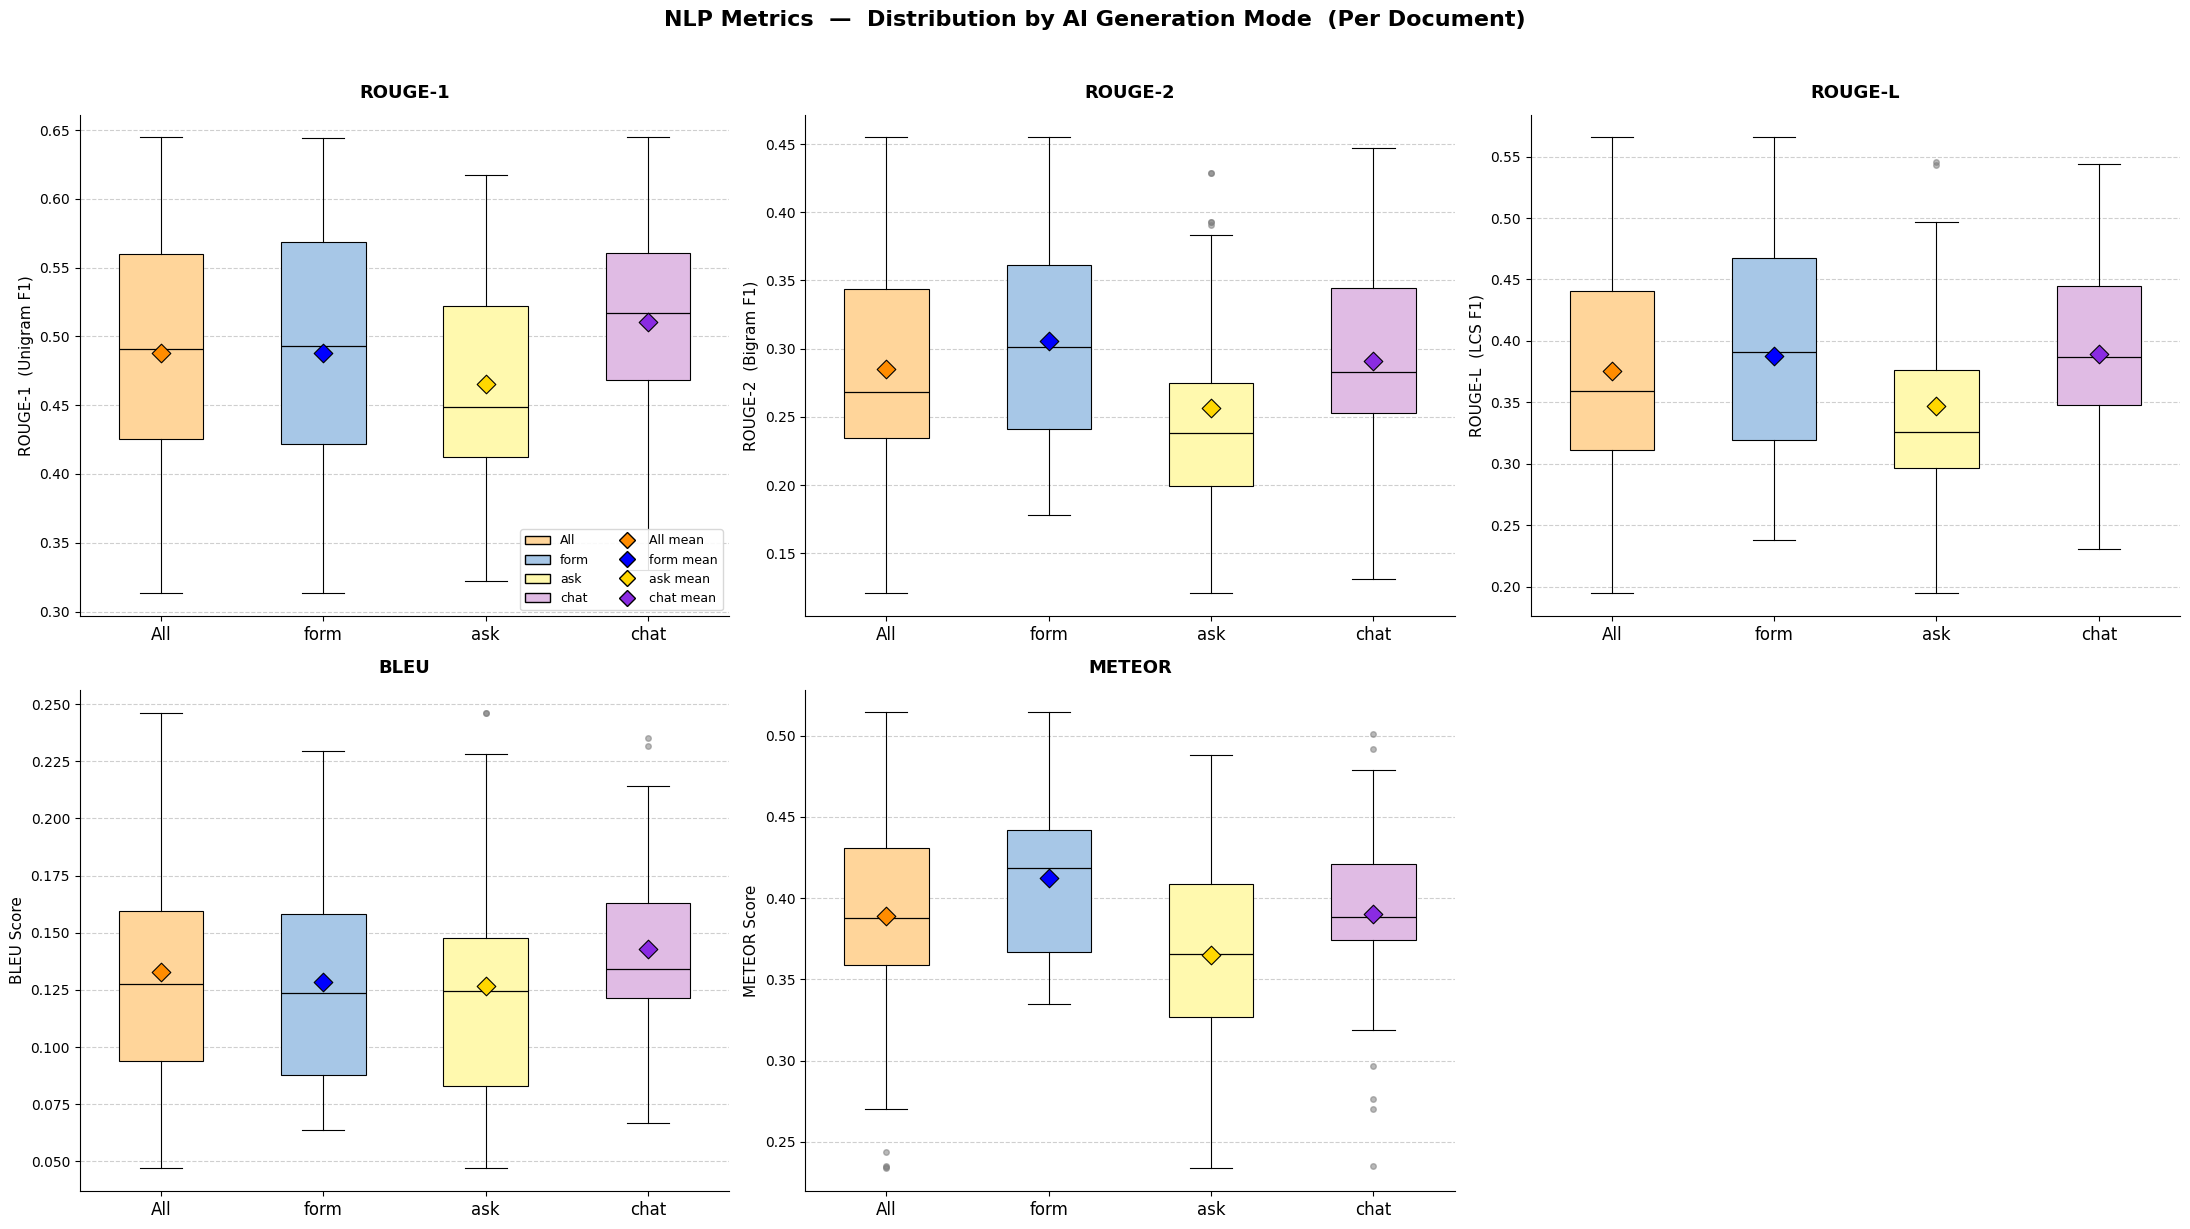

Saved → output/nlp_metrics_boxplot.png


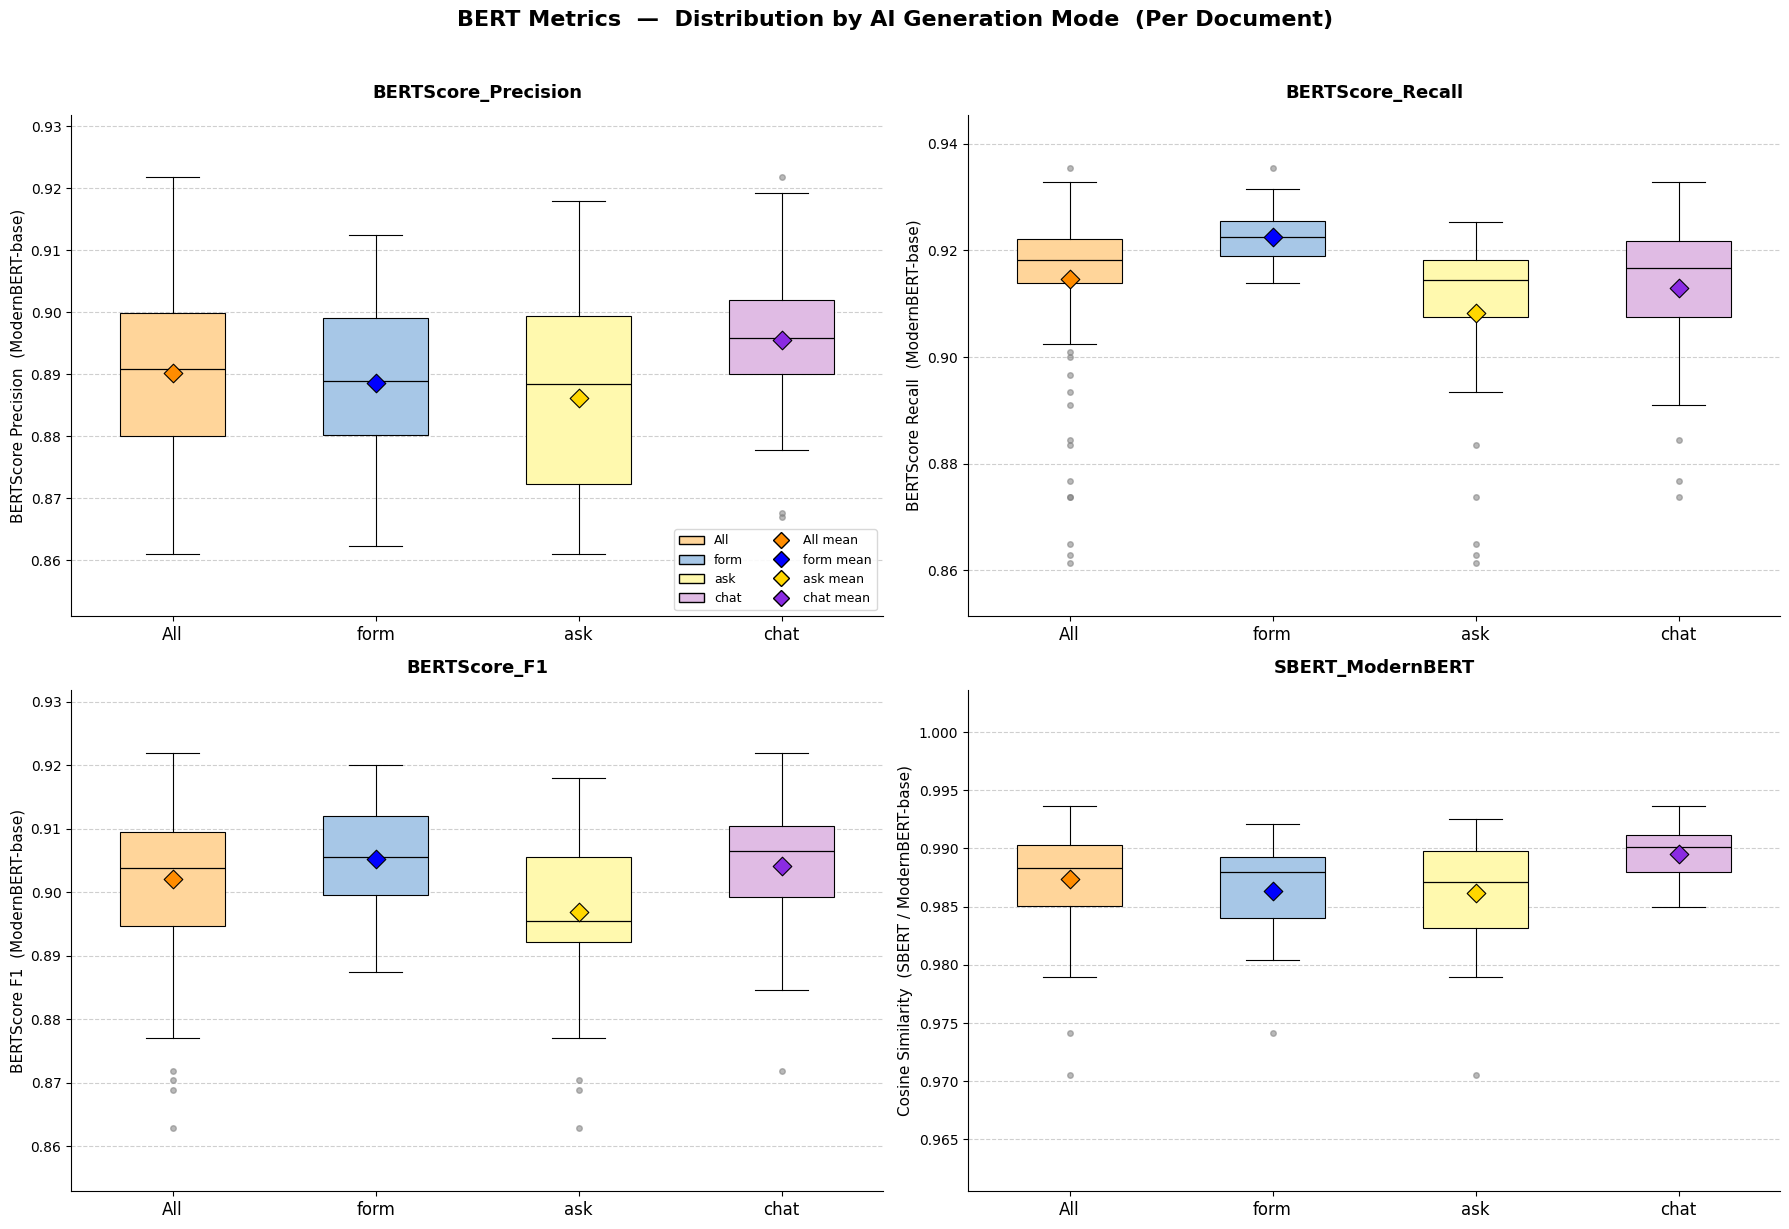

Saved → output/bert_metrics_boxplot.png


In [80]:
# ── Per-metric boxplots ────────────────────────────────────────────────────────
OUT = "output"

METRIC_META = [
    ("ROUGE-1",              "ROUGE-1  (Unigram F1)",                     (0.0, 1.0)),
    ("ROUGE-2",              "ROUGE-2  (Bigram F1)",                      (0.0, 1.0)),
    ("ROUGE-L",              "ROUGE-L  (LCS F1)",                         (0.0, 1.0)),
    ("BLEU",                 "BLEU Score",                                    None),
    ("METEOR",               "METEOR Score",                                   (0.0, 1.0)),
    ("BERTScore_Precision",  "BERTScore Precision  (ModernBERT-base)",        (0.85, 1.00)),
    ("BERTScore_Recall",     "BERTScore Recall  (ModernBERT-base)",           (0.85, 1.00)),
    ("BERTScore_F1",         "BERTScore F1  (ModernBERT-base)",               (0.85, 1.00)),
    ("SBERT_ModernBERT",     "Cosine Similarity  (SBERT / ModernBERT-base)",  (0.85, 1.00)),
]

NLP_METRICS  = METRIC_META[:5]   # BLEU, ROUGE-1/2/L, METEOR
BERT_METRICS = METRIC_META[5:]   # BERTScore P/R/F1, SBERT

GROUPS      = ["All",     "form",    "ask",     "chat"]
BOX_COLORS  = ["#FFD59A", "#A7C7E7", "#FFF9AE", "#E0BBE4"]
MEAN_COLORS = ["#FF8C00", "#0000FF", "#FFD700", "#8A2BE2"]

#
def _get_metric(metric: str, mode_key: str) -> np.ndarray:
    if mode_key == "All":
        return df_combined[metric].dropna().values
    df_m = mode_results.get(mode_key)
    if df_m is None or df_m.empty:
        return np.array([])
    return df_m[metric].dropna().values


def _draw_metric(ax, metric, ylabel, ylim, add_legend=False):
    group_data = [_get_metric(metric, g) for g in GROUPS]

    bp = ax.boxplot(
        group_data,
        positions=range(len(GROUPS)),
        widths=0.52,
        patch_artist=True,
        showfliers=True,
        medianprops=dict(color="black", linewidth=0.9),
        whiskerprops=dict(color="black", linewidth=0.8),
        capprops=dict(color="black", linewidth=0.8),
        boxprops=dict(linewidth=0.8),
        flierprops=dict(marker="o", markerfacecolor="grey",
                        markeredgecolor="grey", markersize=4, alpha=0.55),
    )

    for patch, box_col in zip(bp["boxes"], BOX_COLORS):
        patch.set_facecolor(box_col)
        patch.set_edgecolor("black")

    for i, (data, mean_col) in enumerate(zip(group_data, MEAN_COLORS)):
        if len(data) == 0:
            continue
        ax.scatter(i, np.mean(data), marker="D", s=90,
                   color=mean_col, edgecolors="black", linewidths=0.8, zorder=6)

    ax.set_xticks(range(len(GROUPS)))
    ax.set_xticklabels(GROUPS, fontsize=12)

    # Dynamic y-axis limits based on actual data range
    all_vals = np.concatenate([d for d in group_data if len(d) > 0])
    if len(all_vals) > 0:
        data_min, data_max = all_vals.min(), all_vals.max()
        data_range = data_max - data_min
        padding = max(data_range * 0.05, 0.01)
        ax.set_ylim(data_min - padding, data_max + padding)

    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(metric, fontsize=13, fontweight="bold", pad=12)
    ax.yaxis.grid(True, linestyle="--", linewidth=0.8, alpha=0.6)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

    box_patches = [
        mpatches.Patch(facecolor=bc, edgecolor="black", label=g)
        for g, bc in zip(GROUPS, BOX_COLORS)
    ]
    mean_handles = [
        plt.Line2D([0], [0], marker="D", color="w",
                   markerfacecolor=mc, markeredgecolor="black",
                   markersize=8, label=f"{g} mean")
        for g, mc in zip(GROUPS, MEAN_COLORS)
    ]
    if add_legend:
        ax.legend(handles=box_patches + mean_handles, loc="lower right",
                  fontsize=9, ncol=2, framealpha=0.88, edgecolor="lightgrey")


# ── PNG 1: NLP Metrics (BLEU · ROUGE-1/2/L · METEOR) — 2×3 grid ───────────────
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
axes = axes.flatten()

for i, (metric, ylabel, ylim) in enumerate(NLP_METRICS):
    _draw_metric(axes[i], metric, ylabel, ylim, add_legend=(i == 0))

fig.delaxes(axes[5])  # remove 6th empty slot

plt.suptitle("NLP Metrics  —  Distribution by AI Generation Mode  (Per Document)", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
fname_nlp = f"{OUT}/nlp_metrics_boxplot.png"
plt.savefig(fname_nlp, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {fname_nlp}")


# ── PNG 2: BERT Metrics (Precision · Recall · F1 · SBERT) — 2×2 grid ──────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, (metric, ylabel, ylim) in enumerate(BERT_METRICS):
    _draw_metric(axes[i], metric, ylabel, ylim, add_legend=(i == 0))

plt.suptitle("BERT Metrics  —  Distribution by AI Generation Mode  (Per Document)", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
fname_bert = f"{OUT}/bert_metrics_boxplot.png"
plt.savefig(fname_bert, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {fname_bert}")


## Chapterwise Analysis

Each AI-generated document is split into its 6 canonical GDPR ROPA chapters and scored against the corresponding reference chapter. This reveals which parts of the ROPA structure participants handled well vs. poorly across the three interaction modes.

**6 canonical chapters (German):**
1. Verantwortliche Stelle und Kontaktdaten
2. Zwecke und Rechtsgrundlagen der Verarbeitung
3. Kategorien personenbezogener Daten und Datenquellen
4. Betroffene Personen und Empfänger
5. Aufbewahrungsfristen und Löschung
6. Technische und organisatorische Maßnahmen

In [81]:
import re
import difflib

CANONICAL_CHAPTERS = [
    "Verantwortliche Stelle und Kontaktdaten",
    "Zwecke und Rechtsgrundlagen der Verarbeitung",
    "Kategorien personenbezogener Daten und Datenquellen",
    "Betroffene Personen und Empfänger",
    "Aufbewahrungsfristen und Löschung",
    "Technische und organisatorische Maßnahmen",
]

CH_SHORT = [f"Ch{i+1}" for i in range(len(CANONICAL_CHAPTERS))]
CH_LABEL = dict(zip(CANONICAL_CHAPTERS, CH_SHORT))


def _strip_number(header: str) -> str:
    """Remove leading numeric prefix, e.g. '1. ' or '3.2 '."""
    return re.sub(r'^\d+[\.,]?\d*[\s.]+', '', header).strip()


def _is_sub_chapter(header: str) -> bool:
    """True for sub-chapter headings like '3.2 Datenquellen'."""
    return bool(re.match(r'^\d+\.\d+', header.strip()))


def fuzzy_match_chapter(
    header: str,
    canonical_list: list[str] = CANONICAL_CHAPTERS,
    threshold: float = 0.6,
) -> str | None:
    """
    Map an extracted section header to the closest canonical chapter name
    using difflib SequenceMatcher ratio.  Returns the matched canonical name
    or None if no match exceeds *threshold*.
    """
    h = _strip_number(header)
    m = difflib.get_close_matches(h, canonical_list, n=1, cutoff=threshold)
    return m[0] if m else None


def extract_chapters_markdown(text: str) -> dict[str, str]:
    """
    Split a markdown ROPA document into its H2 sections.

    Steps:
      1. Strip code-fence wrappers (```markdown … ```).
      2. Remove the metadata footer (lines after the last '---' separator).
      3. Find all ``## …`` headings, skipping sub-chapter headings like '3.2 …'.
      4. Return {raw_header: section_content} preserving document order.
    """
    text = text.strip()
    # Strip code fences
    if text.startswith('```'):
        text = text[text.index('\n') + 1:]
    if text.endswith('```'):
        text = text[:text.rindex('```')]

    # Remove metadata footer — everything from the last bare '---' onward
    lines = text.split('\n')
    for i in range(len(lines) - 1, -1, -1):
        if lines[i].strip() == '---':
            lines = lines[:i]
            break
    text = '\n'.join(lines)

    # Find H2 headings, excluding sub-chapters
    pattern = re.compile(r'^## (.+)', re.MULTILINE)
    matches = [
        m for m in pattern.finditer(text)
        if not _is_sub_chapter(m.group(1).strip())
    ]

    chapters: dict[str, str] = {}
    for idx, match in enumerate(matches):
        header = match.group(1).strip()
        start  = match.end()
        end    = matches[idx + 1].start() if idx + 1 < len(matches) else len(text)
        chapters[header] = text[start:end].strip()
    return chapters


def extract_reference_chapters(
    reference_text: str,
    canonical_list: list[str] = CANONICAL_CHAPTERS,
) -> dict[str, str]:
    """
    Split the plain-text reference (no markdown headings) into sections.

    Strategy: scan for lines that look like section headers — short, non-empty,
    not starting with a bullet or digit, and not sub-section labels (e.g. '3.1 …').
    Fuzzy-match each candidate to the canonical list; fall back to positional
    order if fewer than 4 candidates are found.
    """
    # Strip the metadata footer
    lines = reference_text.split('\n')
    for i in range(len(lines) - 1, -1, -1):
        if lines[i].strip() == '---':
            lines = lines[:i]
            break
    text = '\n'.join(lines)

    # Heuristic: a header line is short (<= 70 chars), non-empty, does not
    # start with a bullet ('•'), a digit-dot (sub-section like '2.1'), or
    # a '*' / '#'. We also skip the document title (first two non-empty lines).
    all_lines = text.split('\n')
    header_indices = []
    skipped_titles = 0
    for i, line in enumerate(all_lines):
        s = line.strip()
        if not s:
            continue
        if s.startswith(('•', '*', '#', '-')):
            continue
        if re.match(r'^\d+\.\d+', s):
            continue  # sub-section label
        if len(s) > 70:
            continue  # too long to be a heading
        if skipped_titles < 2:
            skipped_titles += 1
            continue  # skip document title lines
        # Check if it fuzzy-matches any canonical chapter
        match = difflib.get_close_matches(s, canonical_list, n=1, cutoff=0.35)
        if match:
            header_indices.append(i)

    # Fallback: if we can't find enough headers, use positional line scanning
    if len(header_indices) < 4:
        # Use the canonical chapter names directly as keys and split by blank lines
        # between major paragraphs — simple positional split
        paragraphs = [p.strip() for p in re.split(r'\n{2,}', text) if p.strip()]
        # Skip title paragraphs (first 1-2 short ones)
        content_paragraphs = [p for p in paragraphs if len(p) > 40]
        result = {}
        for i, c in enumerate(canonical_list):
            result[c] = content_paragraphs[i] if i < len(content_paragraphs) else ""
        return result

    # Build sections from detected header lines
    sections_raw = {}
    for idx, line_i in enumerate(header_indices):
        header = all_lines[line_i].strip()
        next_line_i = header_indices[idx + 1] if idx + 1 < len(header_indices) else len(all_lines)
        content_lines = all_lines[line_i + 1:next_line_i]
        sections_raw[header] = '\n'.join(content_lines).strip()

    # Fuzzy-match raw headers → canonical, with positional fallback for misses
    result = {}
    used_headers: set[str] = set()
    for canonical in canonical_list:
        best_score, best_header = 0.0, None
        for h in sections_raw:
            if h in used_headers:
                continue
            ratio = difflib.SequenceMatcher(None, h.lower(), canonical.lower()).ratio()
            if ratio > best_score:
                best_score, best_header = ratio, h
        if best_score >= 0.35 and best_header is not None:
            result[canonical] = sections_raw[best_header]
            used_headers.add(best_header)

    # Positional fallback for any remaining unmatched canonical chapters
    unmatched_headers   = [h for h in sections_raw if h not in used_headers]
    missing_canonicals  = [c for c in canonical_list if c not in result]
    for i, canonical in enumerate(missing_canonicals):
        if i < len(unmatched_headers):
            result[canonical] = sections_raw[unmatched_headers[i]]

    return result


def map_doc_chapters_to_canonical(
    raw_dict: dict[str, str],
    canonical_list: list[str] = CANONICAL_CHAPTERS,
) -> dict[str, str]:
    """
    Map extracted document chapters to canonical names.

    Uses best-fit SequenceMatcher assignment (threshold 0.45), then falls back
    to positional order for any canonical chapter that remains unmatched.
    Missing chapters (genuinely absent from the document) get empty string.
    """
    headers_in_order = list(raw_dict.keys())
    result: dict[str, str] = {}
    used_headers: set[str] = set()

    for canonical in canonical_list:
        best_score, best_header = 0.0, None
        for h in headers_in_order:
            if h in used_headers:
                continue
            h_clean = _strip_number(h)
            ratio = difflib.SequenceMatcher(None, h_clean.lower(), canonical.lower()).ratio()
            if ratio > best_score:
                best_score, best_header = ratio, h
        if best_score >= 0.45 and best_header is not None:
            result[canonical] = raw_dict[best_header]
            used_headers.add(best_header)

    # Positional fallback for remaining canonical chapters
    unmatched_headers  = [h for h in headers_in_order if h not in used_headers]
    missing_canonicals = [c for c in canonical_list if c not in result]
    for i, canonical in enumerate(missing_canonicals):
        if i < len(unmatched_headers):
            result[canonical] = raw_dict[unmatched_headers[i]]
            used_headers.add(unmatched_headers[i])
        else:
            result[canonical] = ""  # genuinely missing chapter → score as 0

    return result


# ── Parse reference chapters once ─────────────────────────────────────────
ref_chapters = extract_reference_chapters(reference_text)
print("Reference chapters extracted:")
for ch, content in ref_chapters.items():
    print(f"  {ch!r}: {len(content)} chars")


Reference chapters extracted:
  'Verantwortliche Stelle und Kontaktdaten': 343 chars
  'Zwecke und Rechtsgrundlagen der Verarbeitung': 23 chars
  'Kategorien personenbezogener Daten und Datenquellen': 32 chars
  'Betroffene Personen und Empfänger': 35 chars
  'Aufbewahrungsfristen und Löschung': 165 chars
  'Technische und organisatorische Maßnahmen': 709 chars


In [82]:
from sentence_transformers import SentenceTransformer
import numpy as np
import torch.nn.functional as F

# ── Load MiniLM (chapter-level only; NOT used for whole-document scoring) ──
MINILM_NAME = "sentence-transformers/all-MiniLM-L6-v2"
print(f"Loading SentenceTransformer: {MINILM_NAME} …")
sbert_minilm = SentenceTransformer(MINILM_NAME, device=DEVICE)
sbert_minilm.max_seq_length = 384
print(f"Max seq length : {sbert_minilm.max_seq_length}")
print(f"Embedding dim  : {sbert_minilm.get_sentence_embedding_dimension()}")

# ── Pre-encode reference chapters with both models ─────────────────────────
ref_chapter_texts = [ref_chapters.get(ch, "") for ch in CANONICAL_CHAPTERS]

# ModernBERT (sbert_model already loaded in cell 6)
ref_ch_emb_modernbert = sbert_model.encode(
    ref_chapter_texts,
    batch_size=1,
    convert_to_numpy=True,
    normalize_embeddings=True,
    show_progress_bar=False,
)  # shape: (6, hidden_dim)

# MiniLM
ref_ch_emb_minilm = sbert_minilm.encode(
    ref_chapter_texts,
    batch_size=6,
    convert_to_numpy=True,
    normalize_embeddings=True,
    show_progress_bar=False,
)  # shape: (6, hidden_dim)

print(f"Reference chapter embeddings (ModernBERT): {ref_ch_emb_modernbert.shape}")
print(f"Reference chapter embeddings (MiniLM)    : {ref_ch_emb_minilm.shape}")


Loading SentenceTransformer: sentence-transformers/all-MiniLM-L6-v2 …


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 12600.65it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Max seq length : 384
Embedding dim  : 384
Reference chapter embeddings (ModernBERT): (6, 768)
Reference chapter embeddings (MiniLM)    : (6, 384)


In [83]:
from tqdm.auto import tqdm
import torch

CHAPTER_METRIC_COLS = [
    "BLEU", "ROUGE-1", "ROUGE-2", "ROUGE-L", "METEOR",
    "BERTScore_Precision", "BERTScore_Recall", "BERTScore_F1",
    "SBERT_ModernBERT", "SBERT_MiniLM",
]


def compute_chapter_metrics_for_doc(
    doc_chapters: dict[str, str],
    ref_ch_emb_mb: np.ndarray,
    ref_ch_emb_ml: np.ndarray,
) -> list[dict]:
    """
    Compute all metrics for one document's 6 canonical chapters.
    Returns a list of 6 dicts (one per chapter) with metric scores.
    """
    rows = []
    for ch_idx, canonical in enumerate(CANONICAL_CHAPTERS):
        cand_text = doc_chapters.get(canonical, "")
        ref_text  = ref_chapters.get(canonical, "")

        row = {"chapter": canonical}

        if not cand_text.strip() or not ref_text.strip():
            # Missing chapter → zero scores for all metrics
            for col in CHAPTER_METRIC_COLS:
                row[col] = 0.0
            rows.append(row)
            continue

        # ── Lexical metrics (reuse existing functions) ─────────────────────
        try:
            b = bleu_metric.compute(predictions=[cand_text], references=[[ref_text]])
            row["BLEU"] = b["bleu"]
        except Exception:
            row["BLEU"] = 0.0

        r = rouge_metric.compute(predictions=[cand_text], references=[ref_text])
        row["ROUGE-1"] = r["rouge1"]
        row["ROUGE-2"] = r["rouge2"]
        row["ROUGE-L"] = r["rougeL"]

        m = meteor_metric.compute(predictions=[cand_text], references=[ref_text])
        row["METEOR"] = m["meteor"]

        # ── BERTScore (ModernBERT, batch_size=1 for short chapter strings) ───
        prec_list, rec_list, f1_list = compute_bertscore(
            [cand_text], ref_text, batch_size=1
        )
        row["BERTScore_Precision"] = prec_list[0]
        row["BERTScore_Recall"]    = rec_list[0]
        row["BERTScore_F1"]        = f1_list[0]

        # ── SBERT ModernBERT ──────────────────────────────────────────────
        cand_emb_mb = sbert_model.encode(
            [cand_text],
            batch_size=1,
            convert_to_numpy=True,
            normalize_embeddings=True,
            show_progress_bar=False,
        )  # (1, dim)
        sim_mb = float((cand_emb_mb @ ref_ch_emb_mb[ch_idx:ch_idx+1].T).squeeze())
        row["SBERT_ModernBERT"] = sim_mb

        # ── SBERT MiniLM ─────────────────────────────────────────────────
        cand_emb_ml = sbert_minilm.encode(
            [cand_text],
            batch_size=1,
            convert_to_numpy=True,
            normalize_embeddings=True,
            show_progress_bar=False,
        )  # (1, dim)
        sim_ml = float((cand_emb_ml @ ref_ch_emb_ml[ch_idx:ch_idx+1].T).squeeze())
        row["SBERT_MiniLM"] = sim_ml

        rows.append(row)
    return rows


# ── Build lookup: id → document text (from df_all loaded in cell 2) ──────
_doc_lookup = df_all.set_index("id")["document"].to_dict()

# ── Run over all documents ─────────────────────────────────────────────────
all_chapter_rows = []

for _, doc_row in tqdm(df_eval.iterrows(), total=len(df_eval), desc="Documents"):
    doc_text     = str(_doc_lookup.get(doc_row["id"], ""))
    raw_chapters = extract_chapters_markdown(doc_text)
    doc_chapters = map_doc_chapters_to_canonical(raw_chapters)

    ch_rows = compute_chapter_metrics_for_doc(
        doc_chapters, ref_ch_emb_modernbert, ref_ch_emb_minilm
    )
    for ch_row in ch_rows:
        ch_row["id"]      = doc_row["id"]
        ch_row["user_id"] = doc_row["user_id"]
        ch_row["ai_mode"] = doc_row["ai_mode"]
        all_chapter_rows.append(ch_row)

df_chapters = pd.DataFrame(all_chapter_rows)[
    ["id", "user_id", "ai_mode", "chapter"] + CHAPTER_METRIC_COLS
]

df_chapters.to_csv(f"{OUT}/chapter_results.csv", index=False)
print(f"\nSaved {OUT}/chapter_results.csv  — {len(df_chapters)} rows")
print(f"Shape: {df_chapters.shape}")

Documents: 100%|██████████| 113/113 [01:28<00:00,  1.28it/s]


Saved output/chapter_results.csv  — 678 rows
Shape: (678, 14)


In [84]:
# ── Per-mode, per-chapter summary ────────────────────────────────────────

def build_chapter_summary(df: pd.DataFrame, metric_cols: list[str]) -> pd.DataFrame:
    """
    For each (ai_mode, chapter) group compute mean, std, best_id, worst_id
    for every metric.  Returns a tidy DataFrame.
    """
    rows = []
    for (mode, chapter), grp in df.groupby(["ai_mode", "chapter"], sort=False):
        row = {"ai_mode": mode, "chapter": chapter}
        for col in metric_cols:
            row[f"{col}_mean"] = grp[col].mean()
            row[f"{col}_std"]  = grp[col].std()
            row[f"{col}_best_id"]  = grp.loc[grp[col].idxmax(), "user_id"] if len(grp) > 0 else None
            row[f"{col}_worst_id"] = grp.loc[grp[col].idxmin(), "user_id"] if len(grp) > 0 else None
        rows.append(row)
    return pd.DataFrame(rows)


df_ch_summary_mode = build_chapter_summary(df_chapters, CHAPTER_METRIC_COLS)
# Ensure canonical chapter order
df_ch_summary_mode["chapter"] = pd.Categorical(
    df_ch_summary_mode["chapter"], categories=CANONICAL_CHAPTERS, ordered=True
)
df_ch_summary_mode = df_ch_summary_mode.sort_values(["ai_mode", "chapter"]).reset_index(drop=True)

# ── Aggregated chapter summary (across all modes) ────────────────────────

rows_overall = []
for chapter, grp in df_chapters.groupby("chapter", sort=False):
    row = {"chapter": chapter}
    for col in CHAPTER_METRIC_COLS:
        row[f"{col}_mean"] = grp[col].mean()
        row[f"{col}_std"]  = grp[col].std()
        row[f"{col}_best_id"]  = grp.loc[grp[col].idxmax(), "user_id"] if len(grp) > 0 else None
        row[f"{col}_worst_id"] = grp.loc[grp[col].idxmin(), "user_id"] if len(grp) > 0 else None
    rows_overall.append(row)

df_ch_summary_overall = pd.DataFrame(rows_overall)
df_ch_summary_overall["chapter"] = pd.Categorical(
    df_ch_summary_overall["chapter"], categories=CANONICAL_CHAPTERS, ordered=True
)
df_ch_summary_overall = df_ch_summary_overall.sort_values("chapter").reset_index(drop=True)




In [85]:
# ── Combined comparison: whole-document score vs. mean chapter score ─────
# Rows: each metric (+ SBERT_MiniLM as chapter-only)
# Columns: metric | doc_score (mean) | chapter_avg (mean of 6 chapter means) | difference

def build_comparison_table(
    df_doc: pd.DataFrame,
    df_ch: pd.DataFrame,
    label: str,
) -> pd.DataFrame:
    """Build doc-vs-chapter comparison for one subset (mode or all)."""
    records = []

    # Metrics that exist in both doc-level and chapter-level
    shared_metrics = [
        ("BLEU",               "BLEU"),
        ("ROUGE-1",            "ROUGE-1"),
        ("ROUGE-2",            "ROUGE-2"),
        ("ROUGE-L",            "ROUGE-L"),
        ("METEOR",             "METEOR"),
        ("BERTScore_Precision", "BERTScore_Precision"),
        ("BERTScore_Recall",   "BERTScore_Recall"),
        ("BERTScore_F1",       "BERTScore_F1"),
        ("SBERT_ModernBERT",   "SBERT_ModernBERT"),  # whole-doc SBERT vs chapter SBERT ModernBERT
    ]
    for doc_col, ch_col in shared_metrics:
        doc_mean = df_doc[doc_col].mean() if doc_col in df_doc.columns else float('nan')
        ch_mean  = df_ch[ch_col].mean()  if ch_col  in df_ch.columns  else float('nan')
        records.append({
            "subset":       label,
            "metric":       doc_col,
            "doc_score":    round(doc_mean, 4),
            "chapter_avg":  round(ch_mean,  4),
            "difference":   round(doc_mean - ch_mean, 4),
        })

    # SBERT_MiniLM — chapter-only (no whole-doc equivalent)
    if "SBERT_MiniLM" in df_ch.columns:
        records.append({
            "subset":      label,
            "metric":      "SBERT_MiniLM",
            "doc_score":   float('nan'),
            "chapter_avg": round(df_ch["SBERT_MiniLM"].mean(), 4),
            "difference":  float('nan'),
        })

    return pd.DataFrame(records)


MODES_ALL = sorted(df_eval["ai_mode"].unique())
comparison_parts = []

# Overall
comparison_parts.append(
    build_comparison_table(df_eval, df_chapters, label="overall")
)

# Per mode
for mode in MODES_ALL:
    comparison_parts.append(
        build_comparison_table(
            df_eval[df_eval["ai_mode"] == mode],
            df_chapters[df_chapters["ai_mode"] == mode],
            label=mode,
        )
    )

df_comparison = pd.concat(comparison_parts, ignore_index=True)
df_comparison_pivot = df_comparison.pivot(
    index="metric", columns="subset", values=["doc_score", "chapter_avg", "difference"]
)
df_comparison_T = df_comparison_pivot.T



In [86]:
# ── Export: chapter_nlp_summary.csv & chapter_bert_summary.csv ───────────────
# Tidy per-metric × per-chapter summaries (n/min/q1/median/q3/max/mean/std +
# best/worst) across All, form, ask, chat groups, from chapter_results.csv.

import pandas as pd

OUT = "output"

CANONICAL_CHAPTERS = [
    "Verantwortliche Stelle und Kontaktdaten",
    "Zwecke und Rechtsgrundlagen der Verarbeitung",
    "Kategorien personenbezogener Daten und Datenquellen",
    "Betroffene Personen und Empfänger",
    "Aufbewahrungsfristen und Löschung",
    "Technische und organisatorische Maßnahmen",
]
CH_LABELS = {ch: f"ch{i+1}" for i, ch in enumerate(CANONICAL_CHAPTERS)}

CH_NLP_METRICS  = ["BLEU", "ROUGE-1", "ROUGE-2", "ROUGE-L", "METEOR"]
CH_BERT_METRICS = ["BERTScore_Precision", "BERTScore_Recall", "BERTScore_F1",
                   "SBERT_ModernBERT", "SBERT_MiniLM"]

df_ch = pd.read_csv(f"{OUT}/chapter_results.csv")


def build_chapter_summary_tidy(df: pd.DataFrame, metrics: list) -> pd.DataFrame:
    """
    Returns 30 rows (5 or 5 metrics × 6 chapters), wide stats per group.
    Column order: metric, chapter, then All_*/form_*/ask_*/chat_* stat columns.
    """
    groups = {"All": df, "form": df[df["ai_mode"] == "form"],
              "ask":  df[df["ai_mode"] == "ask"],
              "chat": df[df["ai_mode"] == "chat"]}

    rows = []
    for metric in metrics:
        for ch_full in CANONICAL_CHAPTERS:
            row = {"metric": metric, "chapter": CH_LABELS[ch_full]}
            for grp_name, grp_df in groups.items():
                s = grp_df.loc[grp_df["chapter"] == ch_full, metric]
                prefix = grp_name
                row[f"{prefix}_n"]          = int(s.count())
                row[f"{prefix}_min"]        = round(s.min(),  4)
                row[f"{prefix}_q1"]         = round(s.quantile(0.25), 4)
                row[f"{prefix}_median"]     = round(s.median(), 4)
                row[f"{prefix}_q3"]         = round(s.quantile(0.75), 4)
                row[f"{prefix}_max"]        = round(s.max(),  4)
                row[f"{prefix}_mean"]       = round(s.mean(), 4)
                row[f"{prefix}_std"]        = round(s.std(),  4)
                if len(s) > 0:
                    ch_grp = grp_df[grp_df["chapter"] == ch_full]
                    row[f"{prefix}_best_id"]    = ch_grp.loc[ch_grp[metric].idxmax(), "user_id"]
                    row[f"{prefix}_best_score"] = round(s.max(), 4)
                    row[f"{prefix}_worst_id"]   = ch_grp.loc[ch_grp[metric].idxmin(), "user_id"]
                    row[f"{prefix}_worst_score"]= round(s.min(), 4)
                else:
                    row[f"{prefix}_best_id"]    = None
                    row[f"{prefix}_best_score"] = None
                    row[f"{prefix}_worst_id"]   = None
                    row[f"{prefix}_worst_score"]= None
            rows.append(row)
    return pd.DataFrame(rows)


df_ch_nlp  = build_chapter_summary_tidy(df_ch, CH_NLP_METRICS)
df_ch_bert = build_chapter_summary_tidy(df_ch, CH_BERT_METRICS)

df_ch_nlp.to_csv(f"{OUT}/chapter_nlp_summary.csv",  index=False)
df_ch_bert.to_csv(f"{OUT}/chapter_bert_summary.csv", index=False)

print(f"Saved {OUT}/chapter_nlp_summary.csv  — {len(df_ch_nlp)} rows")
print(f"Saved {OUT}/chapter_bert_summary.csv — {len(df_ch_bert)} rows")



Saved output/chapter_nlp_summary.csv  — 30 rows
Saved output/chapter_bert_summary.csv — 30 rows


In [87]:
# ── Export: doc_vs_chapter_diff.csv ─────────────────────────────────────────
# For each metric × mode: diff = doc_mean - mean(chapter_means across ch1–ch6)
import pandas as pd

OUT = "output"

df_doc_nlp  = pd.read_csv(f"{OUT}/doc_nlp_summary.csv")
df_doc_bert = pd.read_csv(f"{OUT}/doc_bert_summary.csv")
df_ch_nlp   = pd.read_csv(f"{OUT}/chapter_nlp_summary.csv")
df_ch_bert  = pd.read_csv(f"{OUT}/chapter_bert_summary.csv")

# Combine doc summaries
df_doc_all = pd.concat([df_doc_nlp, df_doc_bert], ignore_index=True)

# Combine chapter summaries
df_ch_all  = pd.concat([df_ch_nlp, df_ch_bert], ignore_index=True)

MODES = ["All", "form", "ask", "chat"]

# Build result rows
rows = []
for metric in df_doc_all["metric"].unique():
    row = {"metric": metric}
    for mode in MODES:
        doc_row = df_doc_all[df_doc_all["metric"] == metric]
        doc_mean = doc_row[f"{mode}_mean"].values[0] if not doc_row.empty else None

        ch_rows = df_ch_all[df_ch_all["metric"] == metric]
        if not ch_rows.empty:
            ch_mean_avg = ch_rows[f"{mode}_mean"].mean()
        else:
            ch_mean_avg = None

        diff = (doc_mean - ch_mean_avg) if (doc_mean is not None and ch_mean_avg is not None) else None

        row[f"{mode}_doc"]          = doc_mean
        row[f"{mode}_chapter_mean"] = ch_mean_avg
        row[f"{mode}_diff"]         = diff
    rows.append(row)

df_diff = pd.DataFrame(rows)

# Order columns: metric, then for each mode: doc, chapter_mean, diff
col_order = ["metric"]
for mode in MODES:
    col_order += [f"{mode}_doc", f"{mode}_chapter_mean", f"{mode}_diff"]
df_diff = df_diff[col_order]

df_diff.to_csv(f"{OUT}/doc_vs_chapter_diff.csv", index=False)
print(f"Saved {OUT}/doc_vs_chapter_diff.csv  ({len(df_diff)} rows x {len(df_diff.columns)} cols)")


Saved output/doc_vs_chapter_diff.csv  (9 rows x 13 cols)


In [88]:
# ── Display B: per-chapter NLP + BERT + diff summaries (one mode at a time) ───
import pandas as pd
from IPython.display import display

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

OUT = "output"
df_ch_nlp_disp  = pd.read_csv(f"{OUT}/chapter_nlp_summary.csv")
df_ch_bert_disp = pd.read_csv(f"{OUT}/chapter_bert_summary.csv")
df_diff_disp    = pd.read_csv(f"{OUT}/doc_vs_chapter_diff.csv")

CH_NLP_METRICS_DISP  = ["BLEU", "ROUGE-1", "ROUGE-2", "ROUGE-L", "METEOR"]
CH_BERT_METRICS_DISP = ["BERTScore_Precision", "BERTScore_Recall", "BERTScore_F1",
                         "SBERT_ModernBERT", "SBERT_MiniLM"]
CHAPTERS  = [f"ch{i+1}" for i in range(6)]
STAT_COLS = ["n", "min", "q1", "median", "q3", "max", "mean", "std",
             "best_id", "best_score", "worst_id", "worst_score"]

# Build a MultiIndex display table for one set of metrics + one mode
def build_chapter_multiindex(df_summary, metrics, mode):
    tuples = [(ch, stat) for ch in CHAPTERS for stat in STAT_COLS]
    mi = pd.MultiIndex.from_tuples(tuples, names=["chapter", "stat"])
    data = []
    for metric in metrics:
        subset = df_summary[df_summary["metric"] == metric].copy()
        subset = subset.set_index("chapter")
        row_vals = []
        for ch in CHAPTERS:
            for stat in STAT_COLS:
                col = f"{mode}_{stat}"
                if ch in subset.index and col in subset.columns:
                    row_vals.append(subset.loc[ch, col])
                else:
                    row_vals.append(None)
        data.append(row_vals)
    return pd.DataFrame(data, index=metrics, columns=mi)

# ── Per-mode tables first, then diff tables ────────────────────────────────
for mode in ["All", "form", "ask", "chat"]:
    print(f"\n── {mode} — NLP ──")
    display(build_chapter_multiindex(df_ch_nlp_disp, CH_NLP_METRICS_DISP, mode))

    print(f"\n── {mode} — BERT ──")
    display(build_chapter_multiindex(df_ch_bert_disp, CH_BERT_METRICS_DISP, mode))

# ── Diff tables last ────────────────────────────────────────────────────────
for mode in ["All", "form", "ask", "chat"]:
    print(f"\n── {mode} ── (diff: doc vs chapter)")
    diff_cols = [f"{mode}_doc", f"{mode}_chapter_mean", f"{mode}_diff"]
    df_diff_view = df_diff_disp[["metric"] + diff_cols].copy()
    df_diff_view.columns = ["metric", "doc_mean", "chapter_mean", "diff"]
    display(df_diff_view)



── All — NLP ──


chapter  ch1                                                                   \
stat       n     min      q1  median      q3     max    mean     std  best_id   
BLEU     113  0.0000  0.1320  0.1645  0.2391  0.3660  0.1811  0.0801  NIL1922   
ROUGE-1  113  0.1687  0.5167  0.5664  0.6250  0.8704  0.5709  0.1141  NIL1922   
ROUGE-2  113  0.0202  0.3051  0.3689  0.4685  0.7547  0.3859  0.1446  NIL1922   
ROUGE-L  113  0.1446  0.4628  0.5238  0.6195  0.8704  0.5344  0.1289  NIL1922   
METEOR   113  0.1341  0.3948  0.4579  0.5461  0.7395  0.4710  0.1281  UTP0442   

chapter                                  ch2                               \
stat    best_score worst_id worst_score    n  min      q1  median      q3   
BLEU        0.3660  PVV2109      0.0000  113  0.0  0.0000  0.0000  0.0000   
ROUGE-1     0.8704  PVV2109      0.1687  113  0.0  0.0160  0.0244  0.0333   
ROUGE-2     0.7547  aal1412      0.0202  113  0.0  0.0000  0.0107  0.0163   
ROUGE-L     0.8704  PVV2109      0.1446  113  0.0  0.0153  0.0235  0.0333   
METEOR      0.7395  PVV2109      0.1341  113  0.0  0.0000  0.0192  0.0298   

chapter                                                                   ch3  \
stat        max    mean     std  best_id best_score worst_id worst_score    n   
BLEU     0.0000  0.0000  0.0000  EHN0215     0.0000  EHN0215         0.0  113   
ROUGE-1  0.0930  0.0279  0.0174  NAB0152     0.0930  thg1620         0.0  113   
ROUGE-2  0.0580  0.0114  0.0129  VAG2434     0.0580  AAL1220         0.0  113   
ROUGE-L  0.0845  0.0272  0.0166  VAG2434     0.0845  thg1620         0.0  113   
METEOR   0.1820  0.0274  0.0368  VAG2434     0.1820  AAL1220         0.0  113   

chapter                                                                \
stat     min      q1  median      q3     max    mean     std  best_id   
BLEU     0.0  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  EHN0215   
ROUGE-1  0.0  0.0370  0.0593  0.0976  0.2286  0.0695  0.0490  IOL1223   
ROUGE-2  0.0  0.0185  0.0312  0.0571  0.1818  0.0414  0.0362  IOL1223   
ROUGE-L  0.0  0.0370  0.0593  0.0976  0.2286  0.0695  0.0490  IOL1223   
METEOR   0.0  0.0303  0.0837  0.1562  0.4147  0.1064  0.0957  IOL1223   

chapter                                  ch4                                  \
stat    best_score worst_id worst_score    n     min      q1  median      q3   
BLEU        0.0000  EHN0215         0.0  113  0.0000  0.0000  0.0073  0.0218   
ROUGE-1     0.2286  NOL0906         0.0  113  0.0135  0.0575  0.0990  0.1389   
ROUGE-2     0.1818  NOL0906         0.0  113  0.0000  0.0377  0.0714  0.1127   
ROUGE-L     0.2286  NOL0906         0.0  113  0.0135  0.0575  0.0990  0.1389   
METEOR      0.4147  NOL0906         0.0  113  0.0448  0.1444  0.2255  0.3005   

chapter                                                                   ch5  \
stat        max    mean     std  best_id best_score worst_id worst_score    n   
BLEU     0.0466  0.0117  0.0135  IHB1316     0.0466  EHN0215      0.0000  113   
ROUGE-1  0.2439  0.1025  0.0517  IHB1316     0.2439  thg1620      0.0135  113   
ROUGE-2  0.2051  0.0734  0.0476  IHB1316     0.2051  AHR0531      0.0000  113   
ROUGE-L  0.2439  0.1025  0.0517  IHB1316     0.2439  thg1620      0.0135  113   
METEOR   0.4459  0.2250  0.1123  EHN0215     0.4459  EHN0215      0.0448  113   

chapter                                                                   \
stat        min      q1  median      q3     max    mean     std  best_id   
BLEU     0.0000  0.0000  0.0000  0.0541  0.3855  0.0435  0.0756  NUG0102   
ROUGE-1  0.0750  0.1624  0.2362  0.3243  0.7692  0.2602  0.1305  NUG0102   
ROUGE-2  0.0000  0.0508  0.1138  0.1818  0.5946  0.1306  0.1128  NUG0102   
ROUGE-L  0.0500  0.1414  0.1967  0.2857  0.7692  0.2288  0.1355  NUG0102   
METEOR   0.0549  0.2054  0.2915  0.3886  0.7861  0.3138  0.1597  NUG0102   

chapter                                  ch6                                  \
stat    best_score worst_id worst_score    n     min      q1  median  


── All — BERT ──


chapter              ch1                                                  \
stat                   n     min      q1  median      q3     max    mean   
BERTScore_Precision  113  0.8267  0.8449  0.8538  0.8692  0.9050  0.8573   
BERTScore_Recall     113  0.8230  0.8681  0.8817  0.8941  0.9358  0.8816   
BERTScore_F1         113  0.8273  0.8575  0.8663  0.8792  0.9174  0.8692   
SBERT_ModernBERT     113  0.9612  0.9727  0.9757  0.9789  0.9866  0.9755   
SBERT_MiniLM         113  0.4679  0.5908  0.6456  0.7803  0.9209  0.6865   

chapter                                                               ch2  \
stat                    std  best_id best_score worst_id worst_score    n   
BERTScore_Precision  0.0173  EHN0215     0.9050  TIL1618      0.8267  113   
BERTScore_Recall     0.0221  LHL1942     0.9358  PVV2109      0.8230  113   
BERTScore_F1         0.0186  NIL1922     0.9174  PVV2109      0.8273  113   
SBERT_ModernBERT     0.0049  LHL1942     0.9866  SAP2842      0.9612  113   
SBERT_MiniLM         0.1218  IHB1316     0.9209  PVV2109      0.4679  113   

chapter                                                                      \
stat                    min      q1  median      q3     max    mean     std   
BERTScore_Precision  0.5393  0.5553  0.5629  0.5704  0.6415  0.5660  0.0186   
BERTScore_Recall     0.6349  0.6501  0.6685  0.6799  0.6987  0.6663  0.0165   
BERTScore_F1         0.5907  0.6052  0.6118  0.6180  0.6581  0.6118  0.0115   
SBERT_ModernBERT     0.7120  0.7285  0.7345  0.7418  0.7713  0.7347  0.0096   
SBERT_MiniLM         0.1403  0.2532  0.2835  0.3193  0.5356  0.2984  0.0742   

chapter                                                       ch3          \
stat                 best_id best_score worst_id worst_score    n     min   
BERTScore_Precision  DAB1519     0.6415  IHB1316      0.5393  113  0.6277   
BERTScore_Recall     NUG0102     0.6987   NAN277      0.6349  113  0.8136   
BERTScore_F1         DAB1519     0.6581  UAB0821      0.5907  113  0.7175   
SBERT_ModernBERT     DAB1519     0.7713  UOR0445      0.7120  113  0.8313   
SBERT_MiniLM         LOT2142     0.5356    IHB53      0.1403  113  0.2807   

chapter                                                                       \
stat                     q1  median      q3     max    mean     std  best_id   
BERTScore_Precision  0.6614  0.6785  0.7034  0.8080  0.6863  0.0339  aea2442   
BERTScore_Recall     0.8411  0.8469  0.8562  0.9044  0.8487  0.0126  aea2442   
BERTScore_F1         0.7420  0.7567  0.7717  0.8535  0.7586  0.0233  aea2442   
SBERT_ModernBERT     0.8521  0.8660  0.8782  0.9404  0.8664  0.0188  aea2442   
SBERT_MiniLM         0.3564  0.4028  0.4894  0.7196  0.4295  0.0986  VAG2434   

chapter                                              ch4                  \
stat                best_score worst_id worst_score    n     min      q1   
BERTScore_Precision     0.8080  UAB0821      0.6277  113  0.6428  0.6784   
BERTScore_Recall        0.9044  thg1620      0.8136  113  0.7969  0.8285   
BERTScore_F1            0.8535  UAB0821      0.7175  113  0.7238  0.7490   
SBERT_ModernBERT        0.9404  UAB0821      0.8313  113  0.8351  0.8585   
SBERT_MiniLM            0.7196   NAN277      0.2807  113  0.2302  0.3631   

chapter                                                               \
stat                 median      q3     max    mean     std  best_id   
BERTScore_Precision  0.6924  0.7210  0.7779  0.6997  0.0303  NAB0152   
BERTScore_Recall     0.8415  0.8581  0.8852  0.8418  0.0195  VAG2434   
BERTScore_F1         0.7619  0.7776  0.8076  0.7638  0.0204  NAB0152   
SBERT_ModernBERT     0.8687  0.8836  0.9084  0.8706  0.0182  EHJ2314   
SBERT_MiniLM         0.4504  0.5111  0.6487  0.4395  0.1001  DAB1519   

chapter                                              ch5                  \
stat                best_score worst_id worst_score    n     min      q1   
BERTScore_Precision     0.7779  UAB0821      0.6428  113  0.7373  0.7944   
BERTSc


── form — NLP ──


...

,metric,doc_mean,chapter_mean,diff
0,BLEU,0.1286,0.051333,0.077267
1,ROUGE-1,0.4876,0.214900,0.272700
2,ROUGE-2,0.3060,0.130750,0.175250
3,ROUGE-L,0.3880,0.191217,0.196783
4,METEOR,0.4124,0.232383,0.180017
5,BERTScore_Precision,0.8886,0.737600,0.151000
6,BERTScore_Recall,0.9225,0.838233,0.084267
7,BERTScore_F1,0.9052,0.783283,0.121917
8,SBERT_ModernBERT,0.9864,0.891600,0.094800



── ask ── (diff: doc vs chapter)


,metric,doc_mean,chapter_mean,diff
0,BLEU,0.1269,0.050033,0.076867
1,ROUGE-1,0.4654,0.225500,0.239900
2,ROUGE-2,0.2568,0.134083,0.122717
3,ROUGE-L,0.3474,0.201517,0.145883
4,METEOR,0.3650,0.234667,0.130333
5,BERTScore_Precision,0.8861,0.749650,0.136450
6,BERTScore_Recall,0.9082,0.833833,0.074367
7,BERTScore_F1,0.8969,0.788100,0.108800
8,SBERT_ModernBERT,0.9862,0.895250,0.090950



── chat ── (diff: doc vs chapter)


,metric,doc_mean,chapter_mean,diff
0,BLEU,0.1430,0.056500,0.086500
1,ROUGE-1,0.5106,0.240033,0.270567
2,ROUGE-2,0.2913,0.143867,0.147433
3,ROUGE-L,0.3892,0.216067,0.173133
4,METEOR,0.3902,0.250817,0.139383
5,BERTScore_Precision,0.8954,0.756000,0.139400
6,BERTScore_Recall,0.9130,0.835750,0.077250
7,BERTScore_F1,0.9041,0.792783,0.111317
8,SBERT_ModernBERT,0.9895,0.896650,0.092850


## Chapterwise Visualisations

Boxplots per metric, x-axis = canonical chapter (Ch1–Ch6), grouped/colored by AI mode. Visual style matches the per-document boxplots above.

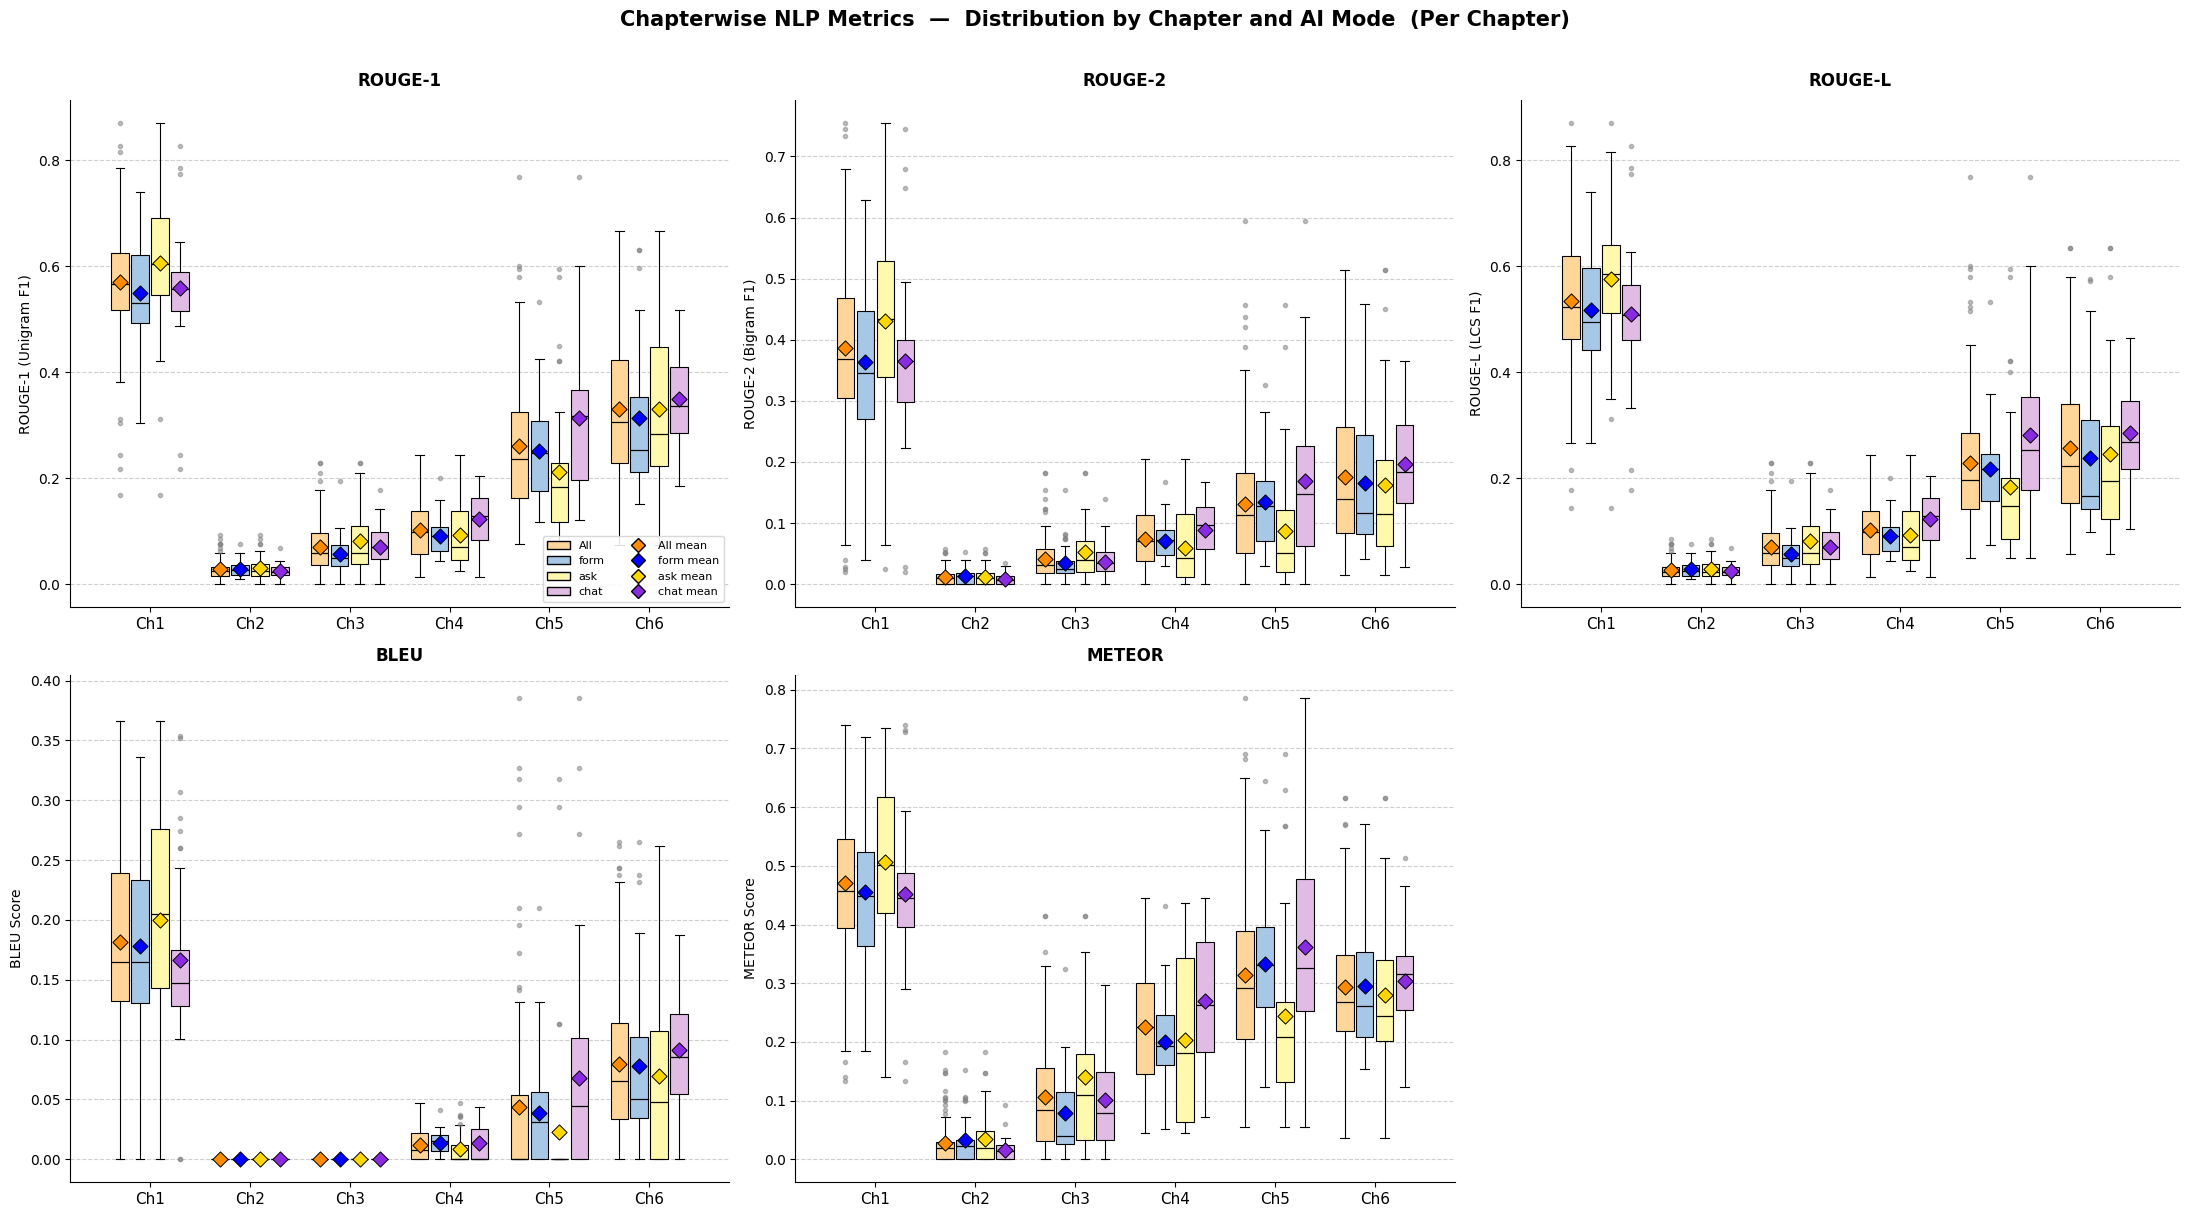

Saved output/chapter_nlp_metrics_boxplot.png


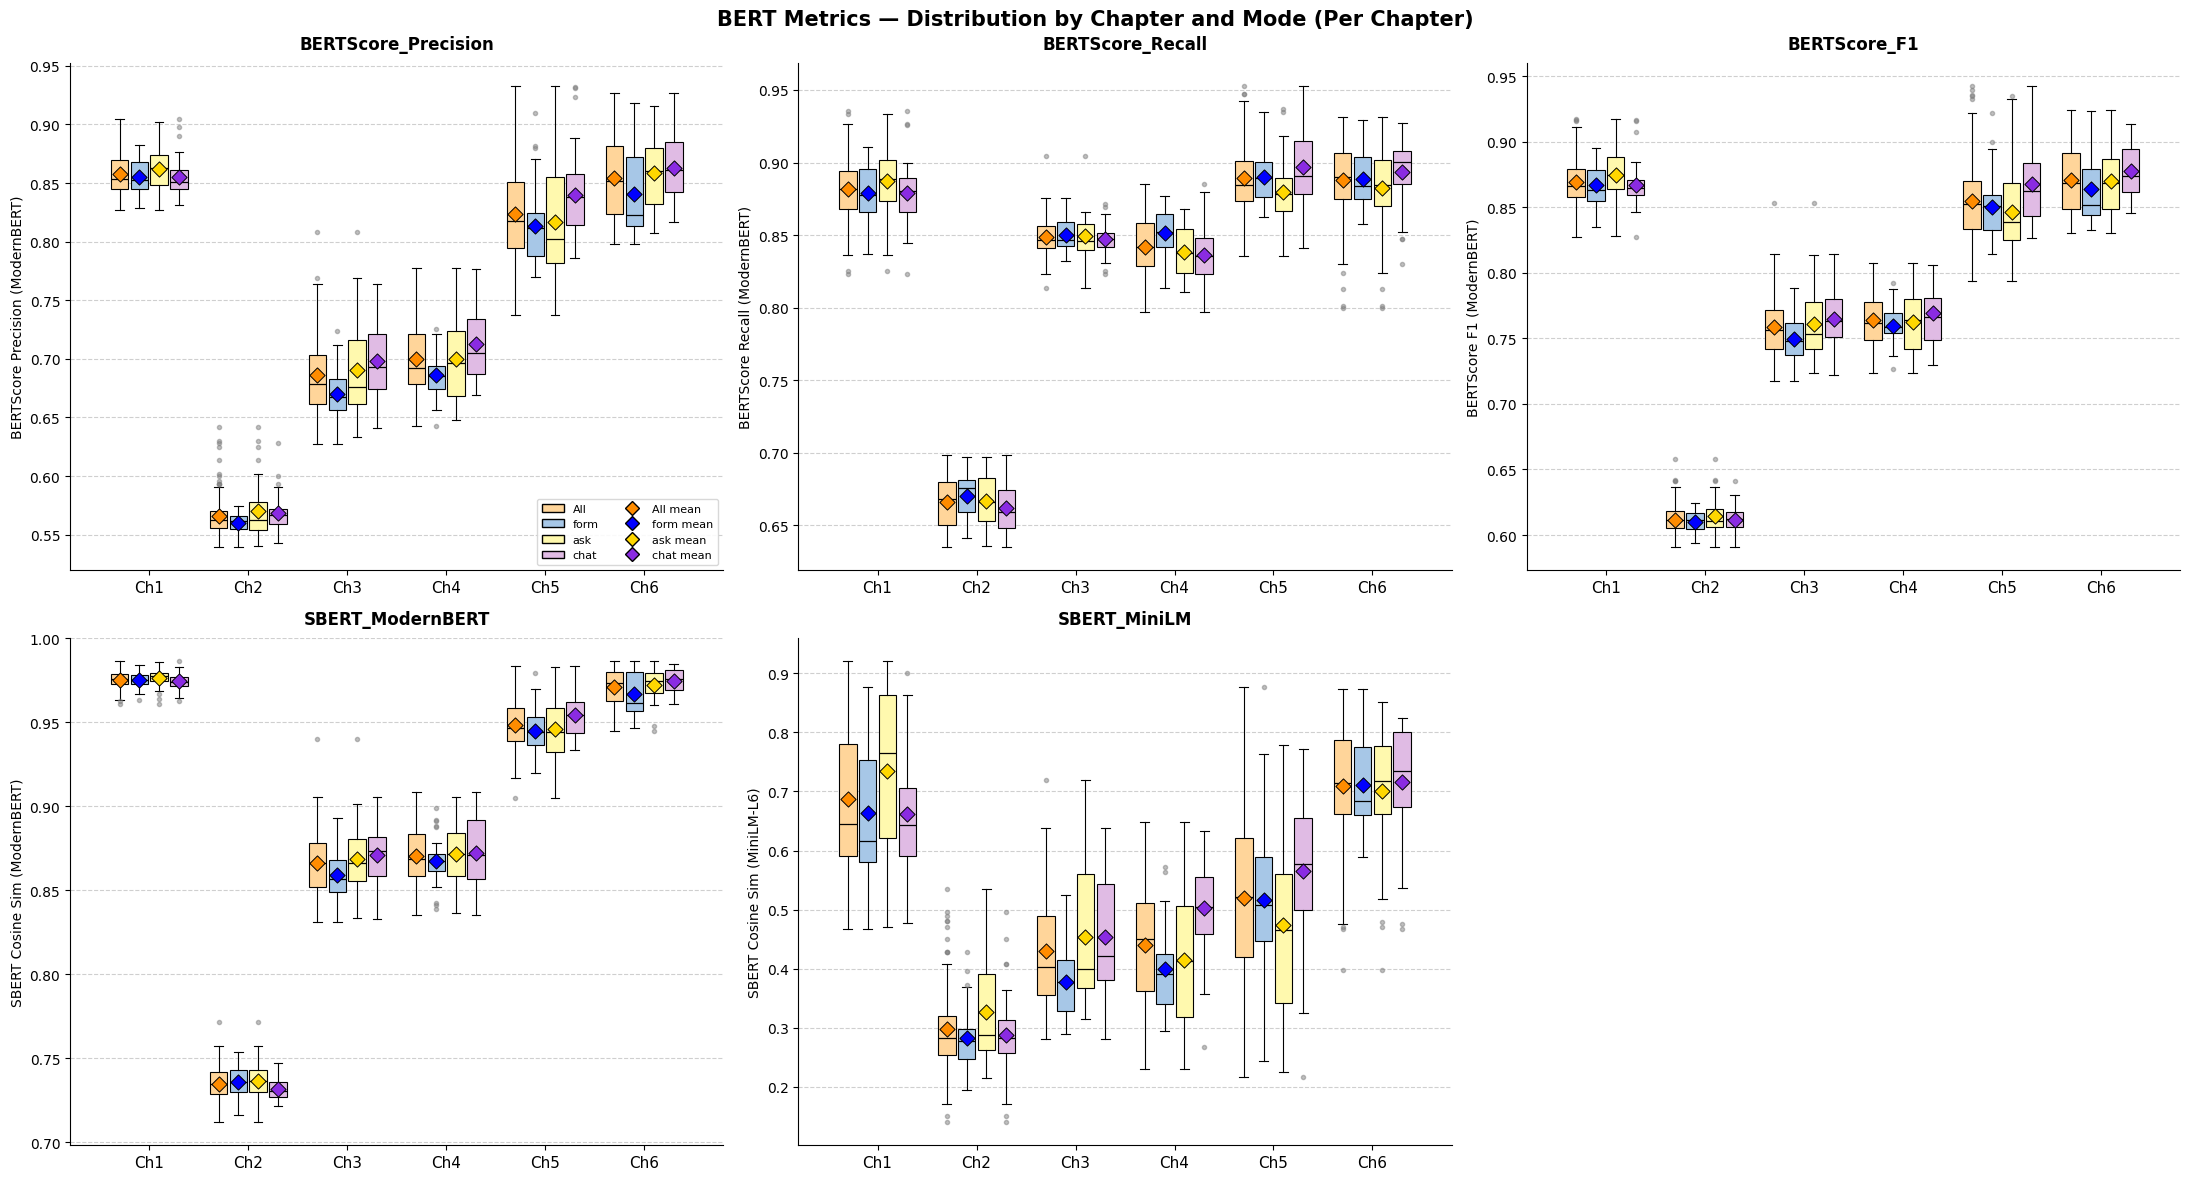

Saved output/chapter_bert_metrics_boxplot.png


In [89]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Palette (same as per-document plots) ───────────────────────────────────────────
GROUPS_CH      = ["All",     "form",    "ask",     "chat"]
BOX_COLORS_CH  = ["#FFD59A", "#A7C7E7", "#FFF9AE", "#E0BBE4"]
MEAN_COLORS_CH = ["#FF8C00", "#0000FF", "#FFD700", "#8A2BE2"]

# Short chapter labels for x-axis
X_LABELS = [f"Ch{i+1}" for i in range(len(CANONICAL_CHAPTERS))]


def _get_chapter_data(metric: str, mode: str, chapter: str) -> np.ndarray:
    if mode == "All":
        mask = df_chapters["chapter"] == chapter
    else:
        mask = (df_chapters["ai_mode"] == mode) & (df_chapters["chapter"] == chapter)
    return df_chapters.loc[mask, metric].dropna().values


def draw_chapter_boxplot(ax, metric: str, ylabel: str, ylim=None, add_legend: bool = False):
    """Draw one axes: x = chapters (Ch1-Ch6), groups = All + modes."""
    n_chapters = len(CANONICAL_CHAPTERS)
    n_groups   = len(GROUPS_CH)
    width      = 0.20
    offsets    = np.linspace(-(n_groups - 1) * width / 2,
                             (n_groups - 1) * width / 2, n_groups)

    all_vals_for_ylim = []

    for g_idx, (mode, box_col, mean_col) in enumerate(zip(GROUPS_CH, BOX_COLORS_CH, MEAN_COLORS_CH)):
        positions = [i + offsets[g_idx] for i in range(n_chapters)]
        data = [_get_chapter_data(metric, mode, ch) for ch in CANONICAL_CHAPTERS]

        bp = ax.boxplot(
            data,
            positions=positions,
            widths=width * 0.88,
            patch_artist=True,
            showfliers=True,
            medianprops=dict(color="black", linewidth=0.9),
            whiskerprops=dict(color="black", linewidth=0.8),
            capprops=dict(color="black", linewidth=0.8),
            boxprops=dict(linewidth=0.8),
            flierprops=dict(marker="o", markerfacecolor="grey",
                            markeredgecolor="grey", markersize=3, alpha=0.5),
        )
        for patch in bp["boxes"]:
            patch.set_facecolor(box_col)
            patch.set_edgecolor("black")

        for i, (d, pos) in enumerate(zip(data, positions)):
            if len(d) > 0:
                ax.scatter(pos, np.mean(d), marker="D", s=60,
                           color=mean_col, edgecolors="black", linewidths=0.7, zorder=6)
                all_vals_for_ylim.append(d)

    ax.set_xticks(range(n_chapters))
    ax.set_xticklabels(X_LABELS, fontsize=11)

    # Dynamic y-axis limits based on actual data range
    if all_vals_for_ylim:
        all_vals = np.concatenate(all_vals_for_ylim)
        data_min, data_max = all_vals.min(), all_vals.max()
        data_range = data_max - data_min
        padding = max(data_range * 0.05, 0.01)
        ax.set_ylim(data_min - padding, data_max + padding)

    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(metric, fontsize=12, fontweight="bold", pad=10)
    ax.yaxis.grid(True, linestyle="--", linewidth=0.8, alpha=0.6)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

    if add_legend:
        box_patches = [
            mpatches.Patch(facecolor=bc, edgecolor="black", label=g)
            for g, bc in zip(GROUPS_CH, BOX_COLORS_CH)
        ]
        mean_handles = [
            plt.Line2D([0], [0], marker="D", color="w",
                       markerfacecolor=mc, markeredgecolor="black",
                       markersize=7, label=f"{g} mean")
            for g, mc in zip(GROUPS_CH, MEAN_COLORS_CH)
        ]
        ax.legend(handles=box_patches + mean_handles,
                  loc="lower right", fontsize=8, ncol=2,
                  framealpha=0.88, edgecolor="lightgrey")


# ── Figure 1: NLP metrics (BLEU · ROUGE-1/2/L · METEOR) ──────────────
CHAPTER_NLP_META = [
    ("ROUGE-1",  "ROUGE-1 (Unigram F1)",   (0.0, 1.0)),
    ("ROUGE-2",  "ROUGE-2 (Bigram F1)",    (0.0, 1.0)),
    ("ROUGE-L",  "ROUGE-L (LCS F1)",       (0.0, 1.0)),
    ("BLEU",     "BLEU Score",             None),
    ("METEOR",   "METEOR Score",           (0.0, 1.0)),
]

fig, axes = plt.subplots(2, 3, figsize=(22, 12))
axes = axes.flatten()
for i, (metric, ylabel, ylim) in enumerate(CHAPTER_NLP_META):
    draw_chapter_boxplot(axes[i], metric, ylabel, ylim, add_legend=(i == 0))
fig.delaxes(axes[5])
plt.suptitle(
    "Chapterwise NLP Metrics  —  Distribution by Chapter and AI Mode  (Per Chapter)",
    fontsize=15, fontweight="bold", y=1.01,
)
plt.tight_layout()
fname_ch_nlp = f"{OUT}/chapter_nlp_metrics_boxplot.png"
plt.savefig(fname_ch_nlp, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {fname_ch_nlp}")


# ── Figure 2: BERT Metrics (BERTScore P/R/F1 · SBERT ModernBERT · MiniLM) ─────
# Layout: 2x3
#   Row 0: BERTScore Precision | BERTScore Recall | BERTScore F1
#   Row 1: SBERT ModernBERT    | SBERT MiniLM     | (hidden)
CHAPTER_BERT_META = [
    ("BERTScore_Precision", "BERTScore Precision (ModernBERT)", (0.80, 1.00)),
    ("BERTScore_Recall",    "BERTScore Recall (ModernBERT)",    (0.80, 1.00)),
    ("BERTScore_F1",        "BERTScore F1 (ModernBERT)",        (0.80, 1.00)),
    ("SBERT_ModernBERT",    "SBERT Cosine Sim (ModernBERT)",    (0.70, 1.00)),
    ("SBERT_MiniLM",        "SBERT Cosine Sim (MiniLM-L6)",    (0.70, 1.00)),
]

# Check SBERT variance — note if near-zero
for metric, _, _ in CHAPTER_BERT_META[3:]:
    var = df_chapters[metric].var()
    if var < 1e-5:
        print(f"Note: {metric} has near-zero variance ({var:.2e}) — boxplot will appear flat.")

fig2, axes2 = plt.subplots(2, 3, figsize=(22, 12))
axes2 = axes2.flatten()
for i, (metric, ylabel, ylim) in enumerate(CHAPTER_BERT_META):
    draw_chapter_boxplot(axes2[i], metric, ylabel, ylim, add_legend=(i == 0))
axes2[5].set_visible(False)  # hide unused bottom-right cell
plt.suptitle(
    "BERT Metrics — Distribution by Chapter and Mode (Per Chapter)",
    fontsize=15, fontweight="bold",
)
plt.tight_layout()
fname_ch_bert = f"{OUT}/chapter_bert_metrics_boxplot.png"
plt.savefig(fname_ch_bert, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {fname_ch_bert}")

## Interpretation

**Overall quality**
- BERTScore F1 (all, n=114): mean=0.902, median=0.904, std=0.011 — consistently high, narrow spread
- SBERT (all): mean=0.987, median=0.988, std=0.004 — near-ceiling document-level similarity
- BLEU (all): mean=0.133, median=0.128 — low, expected; surface form diverges heavily from reference
- METEOR (all): mean=0.389 — modest; synonym matching helps but structural differences dominate

**Surface metrics (BLEU/ROUGE)**
- BLEU range: 0.047–0.246; high variance (std=0.048) relative to mean — output length and phrasing wildly inconsistent
- ROUGE-1 (all): mean=0.489, ROUGE-2: mean=0.285, ROUGE-L: mean=0.375 — bigram overlap (R2) notably lower than unigram, suggesting phrase-level divergence
- Doc-level vs chapter-mean gap for BLEU: ~0.080 overall — aggregation masks chapter-level near-zero scores (ch2, ch3 BLEU ≈ 0.000)
- Chapter 2 (Zwecke/Rechtsgrundlagen) BLEU mean = 0.000 across all modes — none matched reference phrasing at all

**Chapter-level patterns**
- Ch1 (Verantwortliche Stelle): strongest surface scores — ROUGE-1 mean=0.570, BERTScore F1=0.869; contact-info fields tend to be verbatim-ish
- Ch2 (Zwecke/Rechtsgrundlagen): BLEU=0.000, ROUGE-1=0.028, BERTScore F1=0.612, SBERT=0.735 — semantically distant from reference; legal purpose section most problematic
- Ch3 (Kategorien): ROUGE-1=0.069, BERTScore F1=0.758, SBERT=0.866 — moderate semantic similarity, poor surface overlap
- Ch5 (Aufbewahrungsfristen): ROUGE-1=0.259, BERTScore F1=0.854, SBERT=0.948 — retention periods moderately well-matched
- Ch6 (TOM): ROUGE-1=0.328, BERTScore F1=0.863, SBERT=0.963 — best-performing chapter after ch1 on most metrics
- BERTScore F1 spread across chapters: 0.612 (ch2) → 0.869 (ch1); ~0.26 point range — chapter difficulty is real

**Mode comparison**
- BERTScore F1: Chat=0.904, Form=0.905, Ask=0.897 — negligible differences (~0.007 range); all modes semantically comparable
- BLEU: Chat=0.143, Form=0.129, Ask=0.127 — Chat slightly higher surface precision; Form and Ask nearly tied
- ROUGE-1: Chat=0.511, Form=0.488, Ask=0.468 — Chat consistently leads on surface overlap
- METEOR: Form=0.412, Chat=0.390, Ask=0.365 — Form highest; Ask lowest
- SBERT: Chat=0.990, Form=0.986, Ask=0.986 — Chat marginally higher; all within 0.004
- Word count: Form mean=857 words, Ask=674, Chat=593 — Form generates longest documents by far; Chat most concise
- Form's higher word count likely inflates ROUGE/METEOR recall vs shorter Ask/Chat outputs

**Duration vs. usability**
- Total session duration (n=72, excluding -1 outlier): mean=36.9 min, median=36.9 min — sessions consistent
- SUS: Form=78.54, Ask=72.97, Chat=72.93 — Form rated most usable (~5.6 points above Ask/Chat); Ask and Chat nearly identical
- Form SUS ≥ 80 threshold (excellent): mean just below; Ask/Chat in "good" range (~70–79)
- NASA-TLX demand (1–10): Form=4.90, Ask=5.86, Chat=5.72 — Form lowest cognitive load; Ask slightly higher than Chat
- Mode preference (rank_1): Form preferred by 39/73 (53%), Chat by 21/73 (29%), Ask by 13/73 (18%) — Form dominant

**Chapter-level precision vs. recall (Chat vs. Form)**
- BERTScore Precision (chapterwise): Chat=0.7560 > Ask=0.7451 > Form=0.7376 — Chat (pure LLM) is more semantically precise
- BERTScore Recall (chapterwise): Form=0.8382 > Chat=0.8358 > Ask=0.8295 — Form users check more boxes → higher coverage of reference
- Interpretation: Chat generates more on-target content; Form generates more content overall — users tend to over-select, which is actually desirable in GDPR (better to include too much than too little)
- Precision/recall trade-off is real but small in absolute terms; F1 nearly identical (Chat=0.7928, Form=0.7833)

**Confidence vs. quality (RQ2)**
- Confidence (6-item AI scale, 1–5): Ask=3.97, Form=3.85, Chat=3.80 — Ask rated highest; differences small (~0.17 range)
- Quality (BERTScore F1): Form=0.905, Chat=0.904, Ask=0.897 — ranking reverses vs confidence; Ask users most confident but produce lowest-quality docs
- Confidence–quality rank inversion: Ask (conf rank 1, quality rank 3); Form (conf rank 2, quality rank 1) — gap exists but effect size modest
- BLEU/ROUGE tell the same story: Form > Chat > Ask on surface metrics, but Ask users feel most confident
- Word count adds nuance: Ask documents shorter (674 words) — users may feel more assured writing less; Form outputs longer and more complete

## Interpretation Notes

### Why Chapters 2 & 3 have near-zero BLEU / low surface metrics

- **Ch2** = Processing Purposes & Legal Basis; **Ch3** = Data Categories & Sources
- Both are list-heavy, structured legal content with many valid paraphrases
- BLEU requires exact n-gram matches — paraphrase = 0 credit. Legal citations like `Art. 6 Abs. 1 lit. b DSGVO` vs `Art. 6(1)(b) GDPR` are the same article but produce zero BLEU overlap
- Bullet formatting divergence also kills n-gram matches
- BERTScore and SBERT remain healthy (ch2: F1 ~0.61, SBERT ~0.73; ch3: F1 ~0.76, SBERT ~0.87), confirming semantic meaning IS preserved
- **Takeaway:** Surface metrics are inappropriate for evaluating structured legal content with valid paraphrase. BERTScore/SBERT are the primary quality signal for these chapters.

### Chat vs Form score differences — the precision/recall trade-off

- Contrary to intuition, Form generates ~45% more words than Chat (Form: ~857 words, Chat: ~593 words)
- Chat scores marginally higher on precision-oriented metrics (BLEU: +11%, ROUGE-1: +5%) because shorter docs have less off-reference content
- Form scores higher on BERTScore Recall (0.923 vs 0.913) because longer docs cover more of the reference
- BERTScore F1 is essentially tied (Form: 0.905, Chat: 0.904 — Δ0.001)
- The "Chat scores more" observation is true for some metrics but false for others — it is a precision/recall split, not a real quality difference
- **Takeaway:** NLP metric differences between modes are small and inconsistent. No mode clearly dominates on document quality metrics.

### Implication for RQ2

- Users preferred Form (highest SUS, lowest TLX) but NLP quality is roughly equivalent across all three modes
- This is the core confidence–quality gap signal: mode choice affects *experience*, not *output quality* as measured by NLP
- **Caution:** NLP metrics measure surface/semantic similarity to a single reference document — they do not capture legal accuracy or completeness directly

Mirko / Makro Averages
Significance
sparse vectors